# News Consumption Habits - 2021

This data provides the opportunity to comparatively analyse anti-immigrant and anti-refugee attitudes, news and social media consumption, and political attitudes (e.g., social dominance orientation, right-wing authoritarianism) of the adult population in seven European countries (Austria, Belgium, Germany, Hungary, Italy, Spain, Sweden), the United States, and Colombia in 2021 (N = 13,645). 

__Note:__ almost all variables in this dataset are categorical and ordinal (not discrete or continuous) so the modelling and interpretations will need careful consideration. 

The data and codebook and the original questionnaires are publicly accessible here and are also available on Learn: https://data.mendeley.com/datasets/8mgpmdstp2/2

You can find the complete information about the variables and the original questions asked in the data's Codebook and Questionnaire here: https://data.mendeley.com/datasets/8mgpmdstp2/2


In [104]:
# import packages you need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import scipy.stats
from scipy.stats import pearsonr
from scipy.stats import iqr
from scipy.stats import spearmanr

# Import specific modules from Scikit-Learn for various ML tasks
import sklearn.tree as tree       # Decision tree algorithms
import sklearn.ensemble as ens    # Ensemble methods (e.g., random forests)
import sklearn.cluster as clus    # Clustering algorithms
import sklearn.preprocessing as prepr  # Data preprocessing tools
import sklearn.metrics as metrics      # Model performance evaluation

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

import pandas as pd
from scipy.stats import kruskal

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import LabelEncoder, StandardScaler

import statsmodels.formula.api as smf

from sklearn.cluster import KMeans

# Import essential libraries for data science and machine learning
import numpy as np
import pandas as pd

# Import the main Scikit-Learn library for machine learning
import sklearn as skl

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier

In [105]:
#read in the data
data = pd.read_csv('Dataset_DeConinck_R.csv', encoding='latin-1')

# Replace empty strings, spaces, or None with NaN (pd.NA)
# I've done this since many values are left empty since the questions are multiple choice. 
data.replace({99999: np.nan}, inplace=True)
data.fillna(1, inplace=True)

data.drop(data[data['cntry'] != 8].index, inplace=True)

In [106]:
data.head

<bound method NDFrame.head of        cntry  ans_id  V001  V002  V002bea  V002beb  V002at  V002de  V002es  \
10599      8       4     1    61      1.0      1.0     1.0     1.0     1.0   
10600      8       5     1    57      1.0      1.0     1.0     1.0     1.0   
10601      8       6     2    39      1.0      1.0     1.0     1.0     1.0   
10602      8       7     1    88      1.0      1.0     1.0     1.0     1.0   
10603      8       8     1    35      1.0      1.0     1.0     1.0     1.0   
...      ...     ...   ...   ...      ...      ...     ...     ...     ...   
12097      8    2114     2    29      1.0      1.0     1.0     1.0     1.0   
12098      8    2115     2    20      1.0      1.0     1.0     1.0     1.0   
12099      8    2116     2    20      1.0      1.0     1.0     1.0     1.0   
12100      8    2117     2    19      1.0      1.0     1.0     1.0     1.0   
12101      8    2118     2    24      1.0      1.0     1.0     1.0     1.0   

       V002it  ...  V058_5  V058_

In [107]:

data = data.copy()  # This ensures 'data' is a proper DataFrame and not a slice

#change the variable/column names to meaningful words for easier handling
#for example:

data.rename(columns= {'cntry' : 'Country',
                             'V001' : 'Gender',
                              'V002' : 'Age',
                              'V003' : 'MaritalSt',
                              'V009_1' : 'FullTimeJob',
                              'V009_2' : 'PartTimeJob',
                              'V009_3' : 'Disabled',
                              'V009_4' : 'Student',
                              'V009_5' : 'Homemaker',
                              'V009_6' : 'Unemployed',
                              'V009_7' : 'Retired',
                              'V009_8' : 'Active Service',
                              'V009_9' : 'Other',
                              'V010usa' : 'Education',
                              'V011usa' : 'Income',
                              'V013' : 'PoliAff',
                              'V020' : 'Religion',
                              'V021' : 'ReligionImportance',
                              'V022' : 'UrbanDensity',
                              'V024' : 'FreqRefNews',
                              'V025usa_1' : 'FreqPBS',
                              'V025usa_2' : 'FreqCSPAN',
                              'V025usa_3' : 'FreqFOX',
                              'V025usa_4' : 'FreqMSNBC',
                              'V025usa_5' : 'FreqCNN',
                              'V025usa_6' : 'FreqONEAM',
                              'V025usa_7' : 'FreqANN',
                              'V025usa_8' : 'FreqLOCAL',
                              'V025usa_9' : 'FreqNIGHTLY',
                              'V027usa_1' : 'FreqWASHPOST',
                              'V027usa_2' : 'FreqNYT',
                              'V027usa_3' : 'FreqUSATODAY',
                              'V027usa_4' : 'FreqWSJ',
                              'V027usa_5' : 'FreqLAT',
                              'V027usa_6' : 'FreqGLOBE',
                              'V028_1' : 'JourRepInteg',
                              'V028_2' : 'JourPolAgenda',
                              'V028_3' : 'JourSupGovPol',
                              'V028_4' : 'JourBigAudience',
                              'V028_5' : 'JourTolerance',
                              'V029usa_1' : 'FreqWebCNN',
                              'V029usa_2' : 'FreqWebFOX',
                              'V029usa_3' : 'FreqWebUSATODAY',
                              'V029usa_4' : 'FreqWebNYT',
                              'V029usa_5' : 'FreqWebWASHPOST',
                              'V029usa_6' : 'FreqWebWSJ',
                              'V030': 'SocialMediaProfile',
                              'V031': 'FreqSocialMedia',
                              'V032_1': 'FSMCurrentEvents',
    'V032_2' : 'FSMLocalCommunity',
    'V032_3' : 'FSMMainstreamNews',
    'V032_4' : 'FSMCurrentEventsFriends',
    'V032_5' : 'FSMMeetNewPeople',
    'V033_1' : 'FSMReadBlogCurrentAffairs',
    'V033_2' : 'FSMWriteBlogCurrentAffairs',
    'V033_3' : 'FSMCommentCurrentAffairs',
    'V033_4' : 'FSMFollowPolitican',
    'V033_5' : 'FSMFollowPoliParty',
    'V034usa_1' : 'TrustPBS',
    'V034usa_2' : 'TrustFOX',
    'V034usa_3' : 'TrustMSNBC',
    'V034usa_4' : 'TrustCNN',
    'V034usa_5' : 'TrustLOCAL',
    'V034usa_6' : 'TrustWASHPOST',
    'V034usa_7' : 'TrustNYT',
    'V034usa_8' : 'TrustUSATODAY',
    'V034usa_9' : 'TrustWSJ',
    'V034usa_10' : 'TrustNewsApps',
    'V035usa_1' : 'TrustCongress',
    'V035usa_2' : 'TrustStateLegislators',
    'V035usa_3' : 'TrustLegalSystem',
    'V035usa_4' : 'TrustPolice',
    'V035usa_5' : 'TrustPoliticians',
    'V035usa_6' : 'TrustPoliParties',
    'V035usa_7' : 'TrustMilitary',
    'V035usa_8' : 'TrustNationalGuard',
    "V034usa_11": 'TrustSocialMedia',
    'V040' : 'FeelingImmigrants', 
    'V046' : 'FeelingRefugees'}, inplace=True)



In [108]:
data

,Country,ans_id,Gender,Age,V002bea,V002beb,V002at,V002de,V002es,V002it,...,V058_5,V058_6,V058_7,V058_8,V058_9,V058_10,V059,Leeftijd3N,Diploma2,Weging
10599,8,4,1,61,1.0,1.0,1.0,1.0,1.0,1.0,...,5.0,5.0,5.0,1.0,4.0,4.0,1.0,3,2,1.413913
10600,8,5,1,57,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,3.0,5.0,1.0,1.0,3.0,3,1,0.862578
10601,8,6,2,39,1.0,1.0,1.0,1.0,1.0,1.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,2,1,1.322459
10602,8,7,1,88,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,3.0,3,2,1.413913
10603,8,8,1,35,1.0,1.0,1.0,1.0,1.0,1.0,...,4.0,5.0,4.0,1.0,3.0,3.0,3.0,2,2,0.909775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12097,8,2114,2,29,1.0,1.0,1.0,1.0,1.0,1.0,...,5.0,5.0,5.0,2.0,2.0,3.0,1.0,1,1,0.748238
12098,8,2115,2,20,1.0,1.0,1.0,1.0,1.0,1.0,...,2.0,4.0,3.0,4.0,1.0,1.0,2.0,1,1,0.748238
12099,8,2116,2,20,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,5.0,1.0,1.0,2.0,1,1,0.748238
12100,8,2117,2,19,1.0,1.0,1.0,1.0,1.0,1.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,1,1,0.748238


Text(0.5, 1.0, 'Boxplot of Age Ranges within Data')

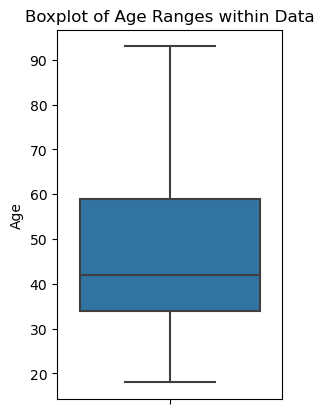

In [109]:
# Boxplot for 'Age'
plt.subplot(1, 2, 1)
sns.boxplot(y=data['Age'])
plt.title('Boxplot of Age Ranges within Data')

In [110]:
data['Age'].describe().round(0)

count    1503.0
mean       45.0
std        14.0
min        18.0
25%        34.0
50%        42.0
75%        59.0
max        93.0
Name: Age, dtype: float64

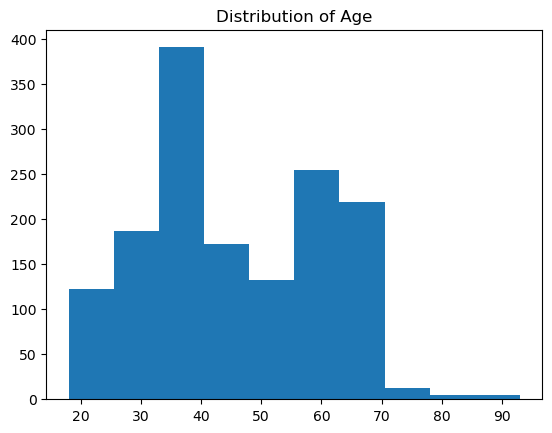

In [111]:
# Assuming 'data' is your DataFrame and 'Age' is a column in it
age = data['Age']

# Create the histogram
plt.hist(age)

# Add a title
plt.title('Distribution of Age')

# Show the plot
plt.show()

In [112]:
# Perhaps the reason for the disproportionate amount of responses for GenZ is because the age bracket is 9-24 and the lowest age of surveyants is 20. 

In [113]:
# First, exploration into Generation as the Moderating Variable 

# Create Age Groups  
bins = [0, 25, 41, 57, 100]  # Age ranges: 9-24, 25-40, 41-56, 57-75 
labels = ['GenZ', 'Millennial', 'GenX', 'Boomer+']   

# Ensure we're modifying 'data' directly by using .loc
data.loc[:, 'Generation'] = pd.cut(data['Age'], bins=bins, labels=labels, right=True)
data.loc[:, 'Generation'] = pd.Categorical(data['Generation'])

# Verify the change
print(data[['Age', 'Generation']].head())



       Age  Generation
10599   61     Boomer+
10600   57        GenX
10601   39  Millennial
10602   88     Boomer+
10603   35  Millennial


/tmp/ipykernel_252/318808955.py:9: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  data.loc[:, 'Generation'] = pd.Categorical(data['Generation'])


In [114]:
generation_counts = data['Generation'].value_counts()
generation_counts

Millennial    621
Boomer+       427
GenX          332
GenZ          123
Name: Generation, dtype: int64

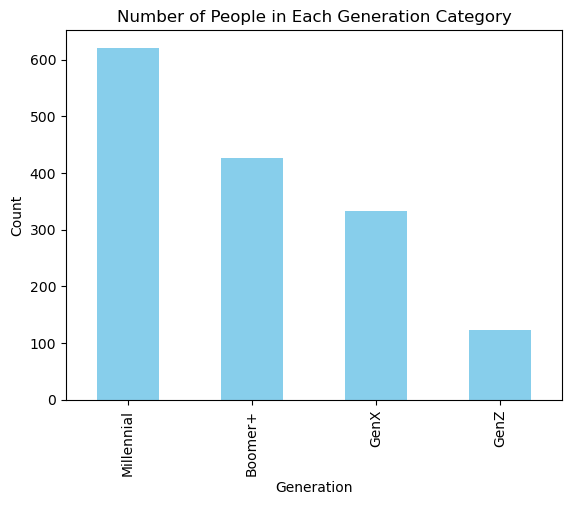

In [115]:
# Plot the counts as a bar plot
generation_counts.plot(kind='bar', color='skyblue')

# Add title and labels
plt.title('Number of People in Each Generation Category')
plt.xlabel('Generation')
plt.ylabel('Count')

# Show the plot
plt.show()

In [116]:
# Weighting for Generation due to disproportionate weighting within categories. 

# Calculate the count of each generation group
gen_counts = data['Generation'].value_counts()

# Calculate weights as the inverse of the count (smaller groups get larger weights)
weights = 1 / gen_counts

# Map the weights to the original dataset based on 'Generation'
# Use direct assignment to avoid SettingWithCopyWarning
data['weight'] = data['Generation'].map(weights)

# Verify that weights have been applied correctly
print(data[['Generation', 'weight']].head())



       Generation    weight
10599     Boomer+  0.002342
10600        GenX  0.003012
10601  Millennial  0.001610
10602     Boomer+  0.002342
10603  Millennial  0.001610


In [117]:
# Ensure the dataframe is properly referenced and modified directly

# Creating a value for Attitudes Towards Outgroups 

# Exploring potential correlations between Feeling Immigrants and Feeling Refugees 

# Create weight column using .map() for 'Generation'
gen_counts = data['Generation'].value_counts()

# Calculate weights as the inverse of the count (smaller groups get larger weights)
weights = 1 / gen_counts

# Map the weights to the original dataset based on 'Generation'
data['weight'] = data['Generation'].map(weights)

# Verify the filled values
print(data['FeelingImmigrants'].head())
print(data['FeelingRefugees'].head())
print(data[['Generation', 'weight']].head())



10599     2
10600    10
10601     0
10602     0
10603     6
Name: FeelingImmigrants, dtype: int64
10599     1
10600    10
10601     0
10602     0
10603     6
Name: FeelingRefugees, dtype: int64
       Generation    weight
10599     Boomer+  0.002342
10600        GenX  0.003012
10601  Millennial  0.001610
10602     Boomer+  0.002342
10603  Millennial  0.001610


In [118]:
data["FeelingImmigrants"].describe()

count    1503.000000
mean        6.807053
std         2.668059
min         0.000000
25%         5.000000
50%         7.000000
75%         9.000000
max        10.000000
Name: FeelingImmigrants, dtype: float64

In [119]:
data["FeelingRefugees"].describe()

count    1503.000000
mean        6.697272
std         2.625195
min         0.000000
25%         5.000000
50%         7.000000
75%         9.000000
max        10.000000
Name: FeelingRefugees, dtype: float64

In [120]:
print(data['FeelingImmigrants'].isna().sum())

0


In [121]:
print(data['FeelingRefugees'].isna().sum())

0


Text(0.5, 1.0, 'Distribution of Feelings Towards Immigrants')

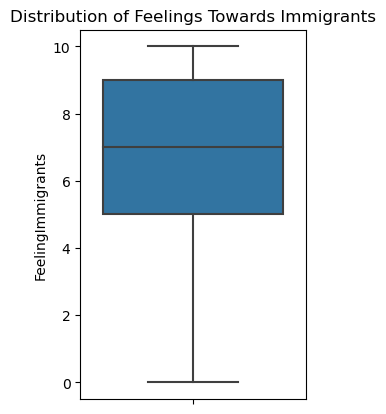

In [122]:
# Boxplot for 'Feelings Towards Immigrants'
plt.subplot(1, 2, 1)
sns.boxplot(y=data['FeelingImmigrants'])
plt.title('Distribution of Feelings Towards Immigrants')


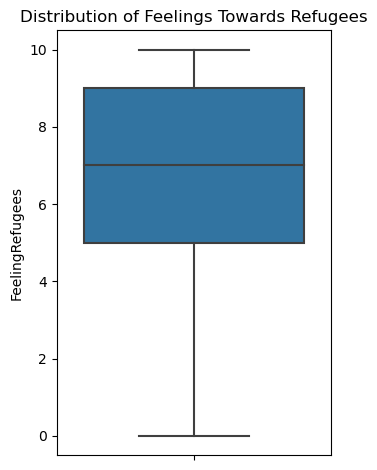

In [123]:
# Boxplot for 'Feelings Towards Refugees'
plt.subplot(1, 2, 2)
sns.boxplot(y=data['FeelingRefugees'])
plt.title('Distribution of Feelings Towards Refugees')

plt.tight_layout()
plt.show()

In [124]:
#Checking to see correlation between 'Feelings Immigrants and Feelings Refugees '

scipy.stats.pearsonr(data['FeelingRefugees'], data['FeelingImmigrants'])[0]

0.7776613327679537

In [125]:
# Ok so how do we interpret the Pearson Correlation? If it is above 0.7 then it is a very high correlation. 

/opt/conda/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


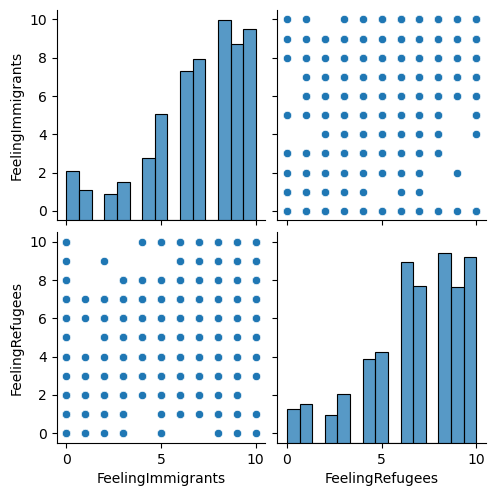

In [126]:
sns.pairplot(data[['FeelingImmigrants', 'FeelingRefugees']])
plt.show()

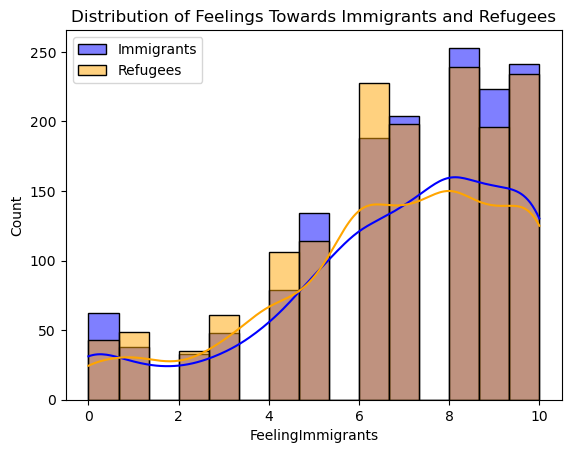

In [127]:
# Since I can't see the correlation on the scatter graphs, I'll plot a histogramme instead. 

sns.histplot(data['FeelingImmigrants'], kde=True, color='blue', label='Immigrants')
sns.histplot(data['FeelingRefugees'], kde=True, color='orange', label='Refugees')
plt.legend()
plt.title('Distribution of Feelings Towards Immigrants and Refugees')
plt.show()

# So from looking at this, people seem to feel positive about both Immigrants and Refugees, although they feel slightly more positive towards Immigrants. We can also confirm there is a strong correlation between the two, therefore justifying the decision to combine the Feelings Refugees and Feelings Immigrants into one.  

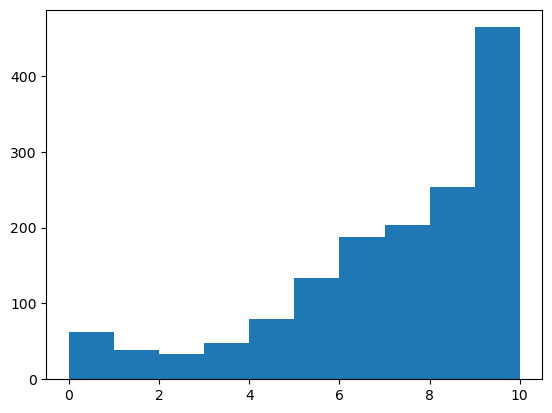

In [128]:
feelingimmigrants = data['FeelingImmigrants'] 
plt.hist(feelingimmigrants)
plt.show()

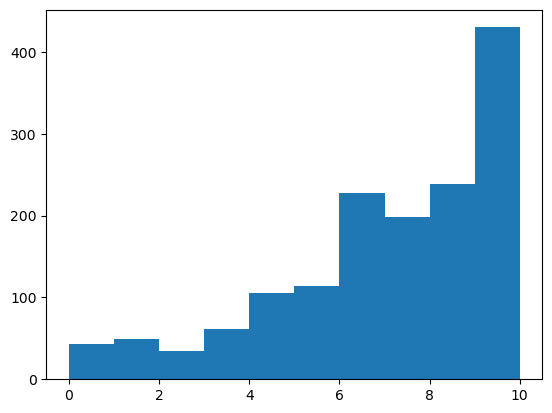

In [129]:
feelingrefugees = data['FeelingRefugees'] 
plt.hist(feelingrefugees)
plt.show()

In [130]:
data['OutgroupThermometer'] = data[['FeelingImmigrants', 'FeelingRefugees']].mean(axis=1)
print(data['OutgroupThermometer'])


10599     1.5
10600    10.0
10601     0.0
10602     0.0
10603     6.0
         ... 
12097     5.0
12098     5.0
12099    10.0
12100     6.0
12101     7.5
Name: OutgroupThermometer, Length: 1503, dtype: float64


In [131]:
#Now we have created a new variable - 'OutgroupThermometer'
# 'OutgroupThermometer' ranges from 0 (cold/negative feelings) to 10 (hot/positive feelings)

data['OutgroupThermometer'].describe()

count    1503.000000
mean        6.752162
std         2.495193
min         0.000000
25%         5.000000
50%         7.000000
75%         8.500000
max        10.000000
Name: OutgroupThermometer, dtype: float64

In [132]:
print(data['OutgroupThermometer'].isna().sum())

0


In [133]:
# We need to drop the rows which have an NaN value for Social Media usage, since this is related to them not having a social media profile. 

#data.dropna(subset=['FSMCurrentEvents', 'FSMMainstreamNews', 'FSMReadBlogCurrentAffairs', 'FSMFollowPolitican', 'FSMFollowPoliParty'], inplace=True)

print(data['FSMCurrentEvents'])

10599    1.0
10600    1.0
10601    1.0
10602    1.0
10603    2.0
        ... 
12097    6.0
12098    1.0
12099    5.0
12100    3.0
12101    3.0
Name: FSMCurrentEvents, Length: 1503, dtype: float64


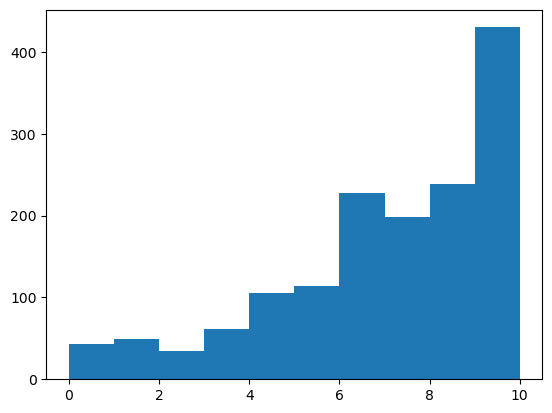

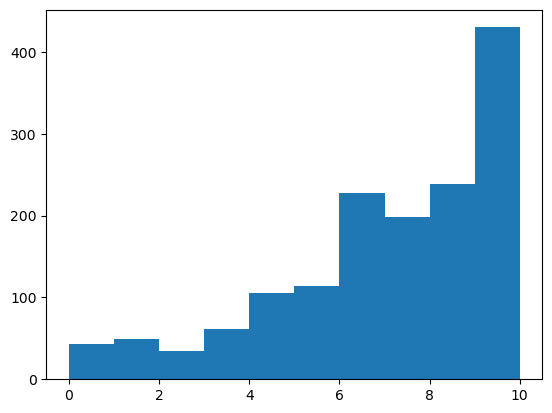

In [134]:
FSMCurrentEvents = data['FSMCurrentEvents'] 
plt.hist(feelingrefugees)
plt.show()

FSMMainstreamNews = data['FSMMainstreamNews'] 
plt.hist(feelingrefugees)
plt.show()

In [135]:
# Creating new value for each News Consumption type (mean)
# All of these values are calculated on the 1-7 scale, so already normalised. 

data['BroadcastNewsConsumption'] = data[['FreqPBS', 'FreqCSPAN', 'FreqFOX', 'FreqMSNBC', 'FreqCNN', 'FreqONEAM', 'FreqANN', 'FreqLOCAL', 'FreqNIGHTLY']].mean(axis=1).round()

data['NewspaperConsumption'] = data[['FreqWASHPOST', 'FreqNYT', 'FreqUSATODAY', 'FreqWSJ', 'FreqLAT', 'FreqGLOBE']].mean(axis=1).round()

data['WebNewsConsumption'] = data[['FreqWebCNN', 'FreqWebFOX', 'FreqWebUSATODAY', 'FreqWebNYT', 'FreqWebWASHPOST', 'FreqWebWSJ']].mean(axis=1).round()

data['SMNewsConsumption'] = data[['FSMCurrentEvents', 'FSMMainstreamNews', 'FSMReadBlogCurrentAffairs', 'FSMFollowPolitican', 'FSMFollowPoliParty' ]].mean(axis=1).round()



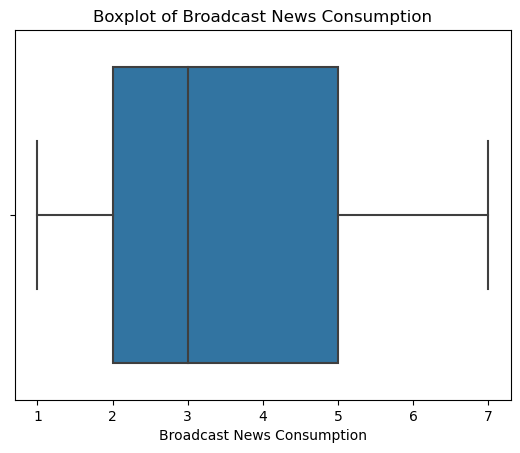

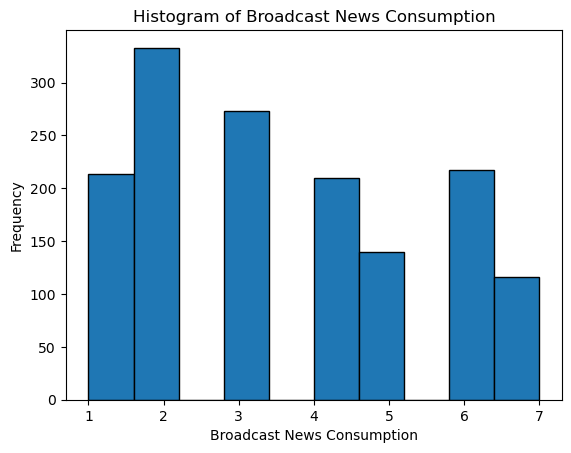

In [136]:
# Plot a boxplot to visualize the spread and any potential outliers
sns.boxplot(x=data['BroadcastNewsConsumption'])
plt.title('Boxplot of Broadcast News Consumption')
plt.xlabel('Broadcast News Consumption')
plt.show()

# Plot a histogram to visualize the data distribution
plt.hist(data['BroadcastNewsConsumption'].dropna(), bins=10, edgecolor='black')
plt.title('Histogram of Broadcast News Consumption')
plt.xlabel('Broadcast News Consumption')
plt.ylabel('Frequency')
plt.show()

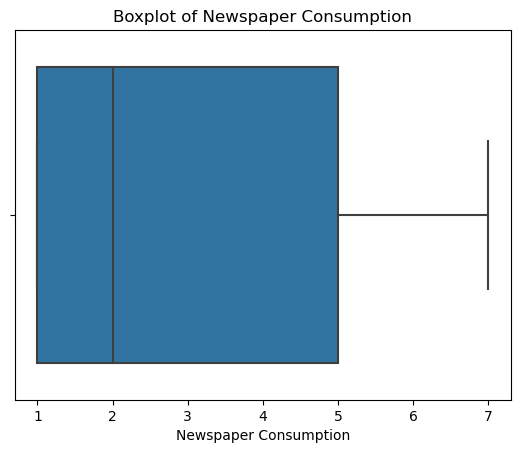

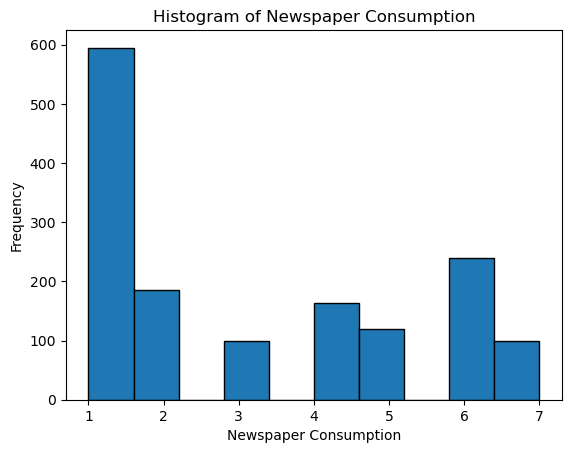

In [137]:
# Plot a boxplot to visualize the spread and any potential outliers
sns.boxplot(x=data['NewspaperConsumption'])
plt.title('Boxplot of Newspaper Consumption')
plt.xlabel('Newspaper Consumption')
plt.show()

# Plot a histogram to visualize the data distribution
plt.hist(data['NewspaperConsumption'].dropna(), bins=10, edgecolor='black')
plt.title('Histogram of Newspaper Consumption')
plt.xlabel('Newspaper Consumption')
plt.ylabel('Frequency')
plt.show()

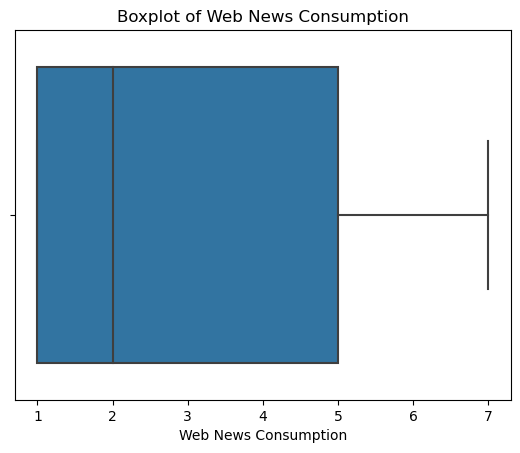

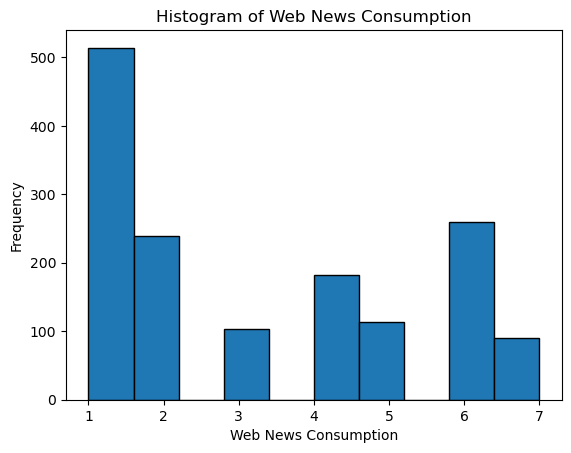

In [138]:
# Plot a boxplot to visualize the spread and any potential outliers
sns.boxplot(x=data['WebNewsConsumption'])
plt.title('Boxplot of Web News Consumption')
plt.xlabel('Web News Consumption')
plt.show()

# Plot a histogram to visualize the data distribution
plt.hist(data['WebNewsConsumption'].dropna(), bins=10, edgecolor='black')
plt.title('Histogram of Web News Consumption')
plt.xlabel('Web News Consumption')
plt.ylabel('Frequency')
plt.show()

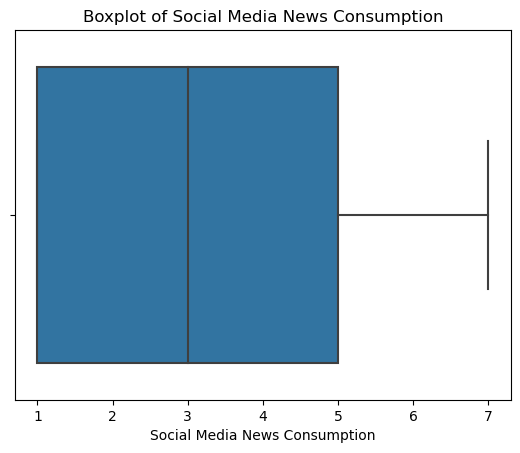

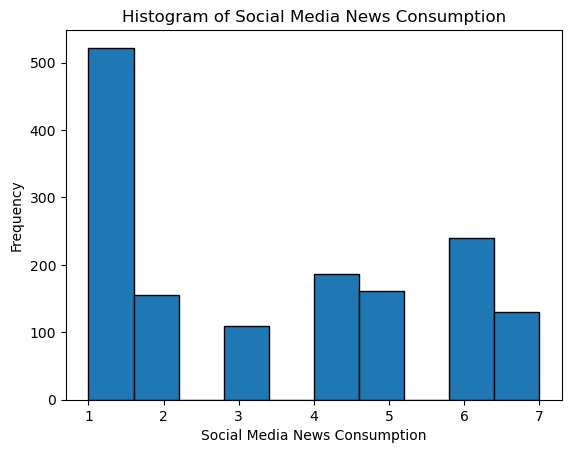

In [139]:
# Plot a boxplot to visualize the spread and any potential outliers
sns.boxplot(x=data['SMNewsConsumption'])
plt.title('Boxplot of Social Media News Consumption')
plt.xlabel('Social Media News Consumption')
plt.show()

# Plot a histogram to visualize the data distribution
plt.hist(data['SMNewsConsumption'].dropna(), bins=10, edgecolor='black')
plt.title('Histogram of Social Media News Consumption')
plt.xlabel('Social Media News Consumption')
plt.ylabel('Frequency')
plt.show()

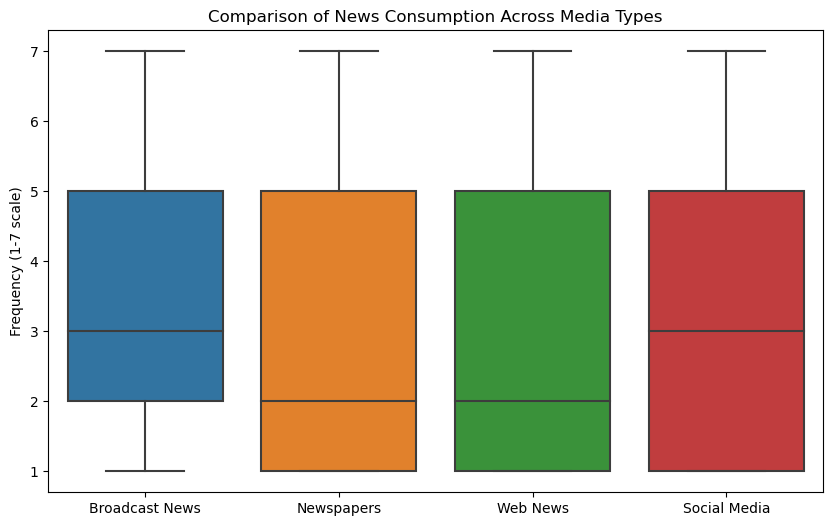

In [140]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data[['BroadcastNewsConsumption', 'NewspaperConsumption', 
                       'WebNewsConsumption', 'SMNewsConsumption']])
plt.title('Comparison of News Consumption Across Media Types')
plt.ylabel('Frequency (1-7 scale)')
plt.xticks([0, 1, 2, 3], ['Broadcast News', 'Newspapers', 'Web News', 'Social Media'])
plt.show()

In [141]:
# Median and Mode for each media consumption type
median_values = data[['BroadcastNewsConsumption', 'NewspaperConsumption', 
                      'WebNewsConsumption', 'SMNewsConsumption']].median()

mode_values = data[['BroadcastNewsConsumption', 'NewspaperConsumption', 
                    'WebNewsConsumption', 'SMNewsConsumption']].mode().iloc[0]

print("Median values:")
print(median_values)
print("\nMode values:")
print(mode_values)


Median values:
BroadcastNewsConsumption    3.0
NewspaperConsumption        2.0
WebNewsConsumption          2.0
SMNewsConsumption           3.0
dtype: float64

Mode values:
BroadcastNewsConsumption    2.0
NewspaperConsumption        1.0
WebNewsConsumption          1.0
SMNewsConsumption           1.0
Name: 0, dtype: float64


In [142]:
# Frequency distribution for each media type
for column in ['BroadcastNewsConsumption', 'NewspaperConsumption', 
               'WebNewsConsumption', 'SMNewsConsumption']:
    print(f"Frequency distribution for {column}:")
    print(data[column].value_counts().sort_index())
    print("\n")

Frequency distribution for BroadcastNewsConsumption:
1.0    214
2.0    333
3.0    273
4.0    210
5.0    140
6.0    217
7.0    116
Name: BroadcastNewsConsumption, dtype: int64


Frequency distribution for NewspaperConsumption:
1.0    595
2.0    186
3.0     99
4.0    164
5.0    120
6.0    239
7.0    100
Name: NewspaperConsumption, dtype: int64


Frequency distribution for WebNewsConsumption:
1.0    514
2.0    239
3.0    104
4.0    182
5.0    114
6.0    260
7.0     90
Name: WebNewsConsumption, dtype: int64


Frequency distribution for SMNewsConsumption:
1.0    522
2.0    155
3.0    109
4.0    186
5.0    161
6.0    240
7.0    130
Name: SMNewsConsumption, dtype: int64




In [143]:
# Kruskal-Wallis H test


# Generate the groups based on generation
boomer_consumption = data[data['Generation'] == 'Boomer+']['BroadcastNewsConsumption']
genx_consumption = data[data['Generation'] == 'GenX']['BroadcastNewsConsumption']
millennial_consumption = data[data['Generation'] == 'Millennial']['BroadcastNewsConsumption']
genz_consumption = data[data['Generation'] == 'GenZ']['BroadcastNewsConsumption']

# Run the Kruskal-Wallis H test
stat, p_value = kruskal(boomer_consumption, genx_consumption, millennial_consumption, genz_consumption)

# Output the results
print("Kruskal-Wallis H-test statistic:", stat)
print("p-value:", p_value)

# Interpretation of the results:
if p_value < 0.05:
    print("There is a significant difference in news consumption frequency across generations.")
else:
    print("There is no significant difference in news consumption frequency across generations.")


Kruskal-Wallis H-test statistic: 330.83624818232823
p-value: 2.103172634311002e-71
There is a significant difference in news consumption frequency across generations.


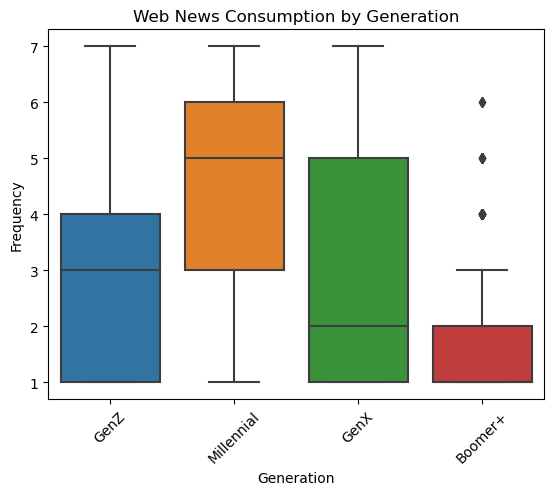

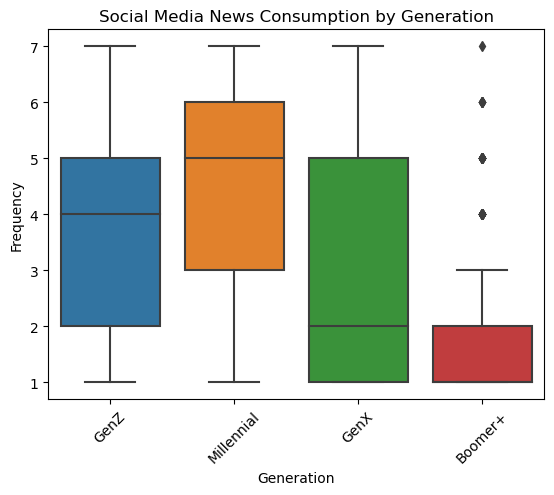

In [144]:
# Web News 

sns.boxplot(x='Generation', y='WebNewsConsumption', data=data)
plt.title('Web News Consumption by Generation')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# Social Media News 

sns.boxplot(x='Generation', y='SMNewsConsumption', data=data)
plt.title('Social Media News Consumption by Generation')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


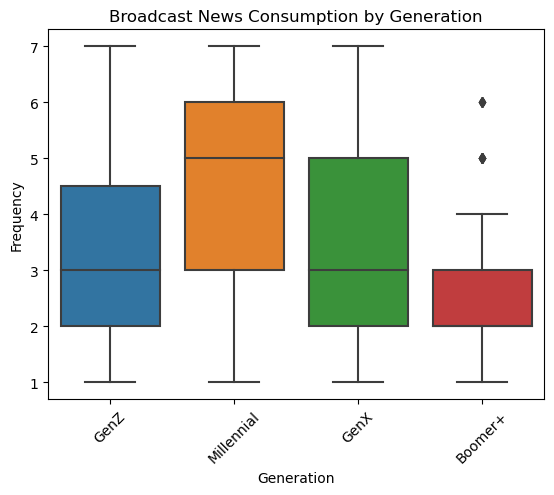

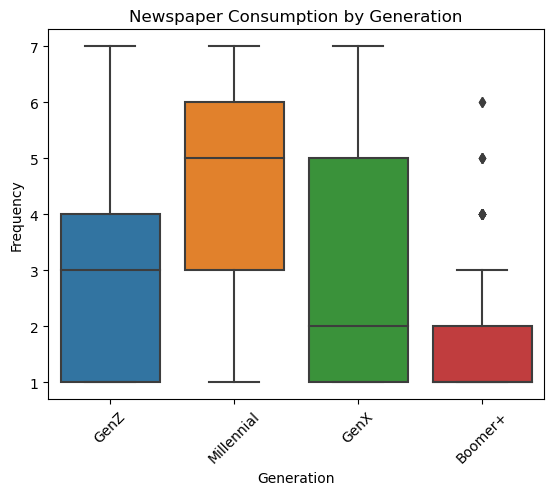

In [145]:
# Explore Relationships Between News Consumption and Generation

# Broadcast News

sns.boxplot(x='Generation', y='BroadcastNewsConsumption', data=data)
plt.title('Broadcast News Consumption by Generation')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# Newspaper

sns.boxplot(x='Generation', y='NewspaperConsumption', data=data)
plt.title('Newspaper Consumption by Generation')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


In [146]:
data_newscons = data[['BroadcastNewsConsumption', 'NewspaperConsumption', 'WebNewsConsumption', 'SMNewsConsumption' ]]

nan_counts = data_newscons.isna().sum()

# Output the count of NaN values per column
print(nan_counts)

BroadcastNewsConsumption    0
NewspaperConsumption        0
WebNewsConsumption          0
SMNewsConsumption           0
dtype: int64


In [147]:
# We can see there are outliers for Boomer+ in News Consumption, so we need to explore these closer. 

# Filter data to include only Boomers
boomer_data = data[data['Generation'] == 'Boomer+']

In [148]:
# List of news consumption columns

# Function to calculate IQR for a given column
def calculate_iqr(df, column):
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return Q1, Q3, IQR, lower_bound, upper_bound

# Iterate over each news consumption type and calculate IQR
iqr_results = {}
for column in data_newscons:
    Q1, Q3, IQR, lower_bound, upper_bound = calculate_iqr(boomer_data, column)
    iqr_results[column] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    }

# Convert results to DataFrame for better visualization
iqr_df = pd.DataFrame(iqr_results).T

# Print the IQR results for each news consumption category
print(iqr_df)

                           Q1   Q3  IQR  Lower Bound  Upper Bound
BroadcastNewsConsumption  2.0  3.0  1.0          0.5          4.5
NewspaperConsumption      1.0  2.0  1.0         -0.5          3.5
WebNewsConsumption        1.0  2.0  1.0         -0.5          3.5
SMNewsConsumption         1.0  2.0  1.0         -0.5          3.5


/tmp/ipykernel_252/3717799609.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_252/3717799609.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_252/3717799609.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


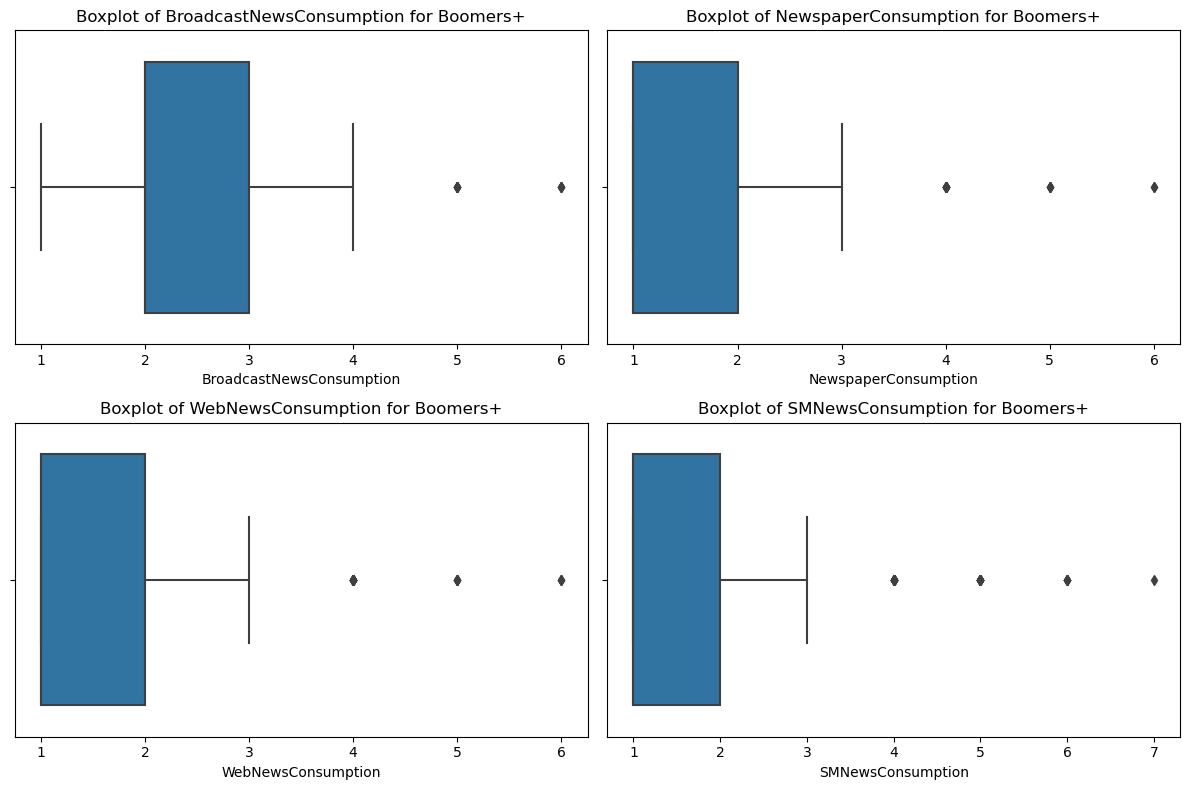

In [149]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of media consumption columns
media_columns = ['BroadcastNewsConsumption', 'NewspaperConsumption', 'WebNewsConsumption', 'SMNewsConsumption']

# Create boxplots for each media consumption category
plt.figure(figsize=(12, 8))

for i, column in enumerate(media_columns, 1):
    plt.subplot(2, 2, i)  # Subplot for each media type
    sns.boxplot(x=boomer_data[column])
    plt.title(f'Boxplot of {column} for Boomers+')
    plt.tight_layout()

plt.show()


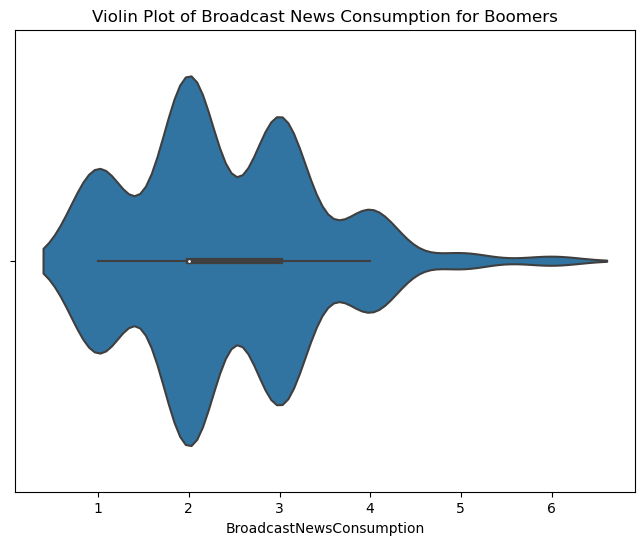

In [150]:
# Violin plot for Broadcast News Consumption

plt.figure(figsize=(8, 6))
sns.violinplot(x='BroadcastNewsConsumption', data=boomer_data, inner="box")
plt.title('Violin Plot of Broadcast News Consumption for Boomers')
plt.show()

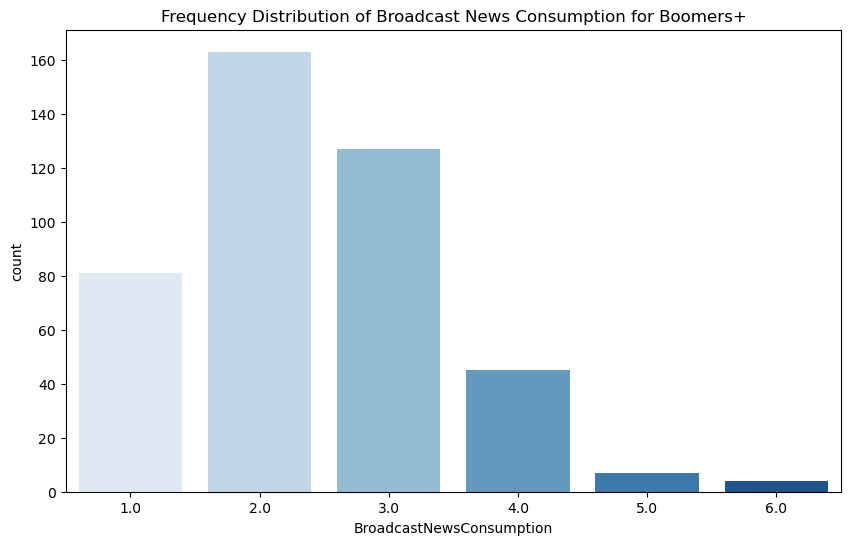

In [151]:
# Bar plot for Broadcast News Consumption, displaying frequency of responses for Boomer +

plt.figure(figsize=(10, 6))
sns.countplot(x='BroadcastNewsConsumption', data=boomer_data, palette='Blues')
plt.title('Frequency Distribution of Broadcast News Consumption for Boomers+')
plt.show()

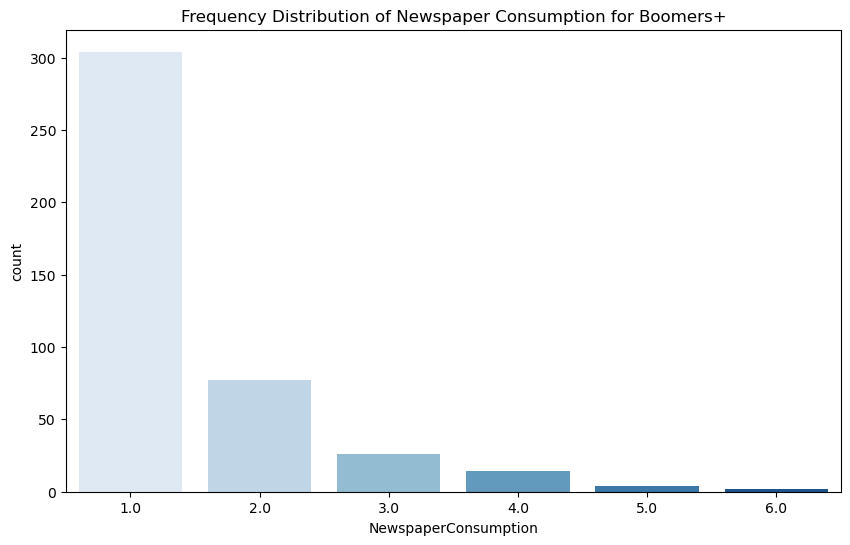

In [152]:
# Bar plot for Newspaper Consumption, displaying frequency of responses for Boomer +

plt.figure(figsize=(10, 6))
sns.countplot(x='NewspaperConsumption', data=boomer_data, palette='Blues')
plt.title('Frequency Distribution of Newspaper Consumption for Boomers+')
plt.show()

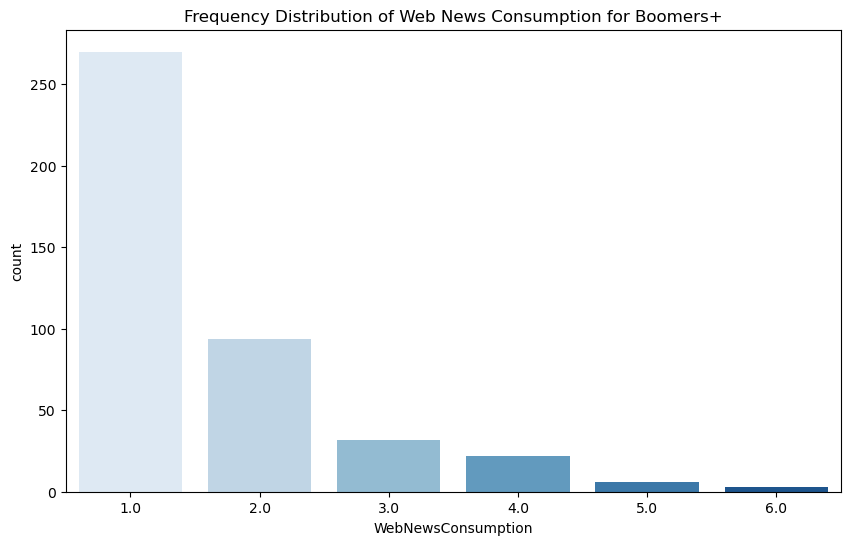

In [153]:
# Bar plot for Web News Consumption, displaying frequency of responses for Boomer +

plt.figure(figsize=(10, 6))
sns.countplot(x='WebNewsConsumption', data=boomer_data, palette='Blues')
plt.title('Frequency Distribution of Web News Consumption for Boomers+')
plt.show()

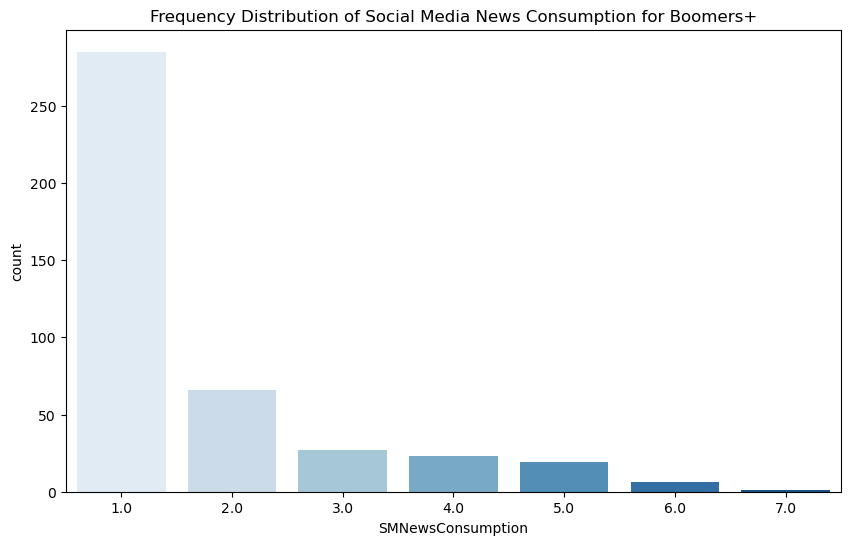

In [154]:
# Bar plot for Social Media News Consumption, displaying frequency of responses for Boomer +

plt.figure(figsize=(10, 6))
sns.countplot(x='SMNewsConsumption', data=boomer_data, palette='Blues')
plt.title('Frequency Distribution of Social Media News Consumption for Boomers+')
plt.show()

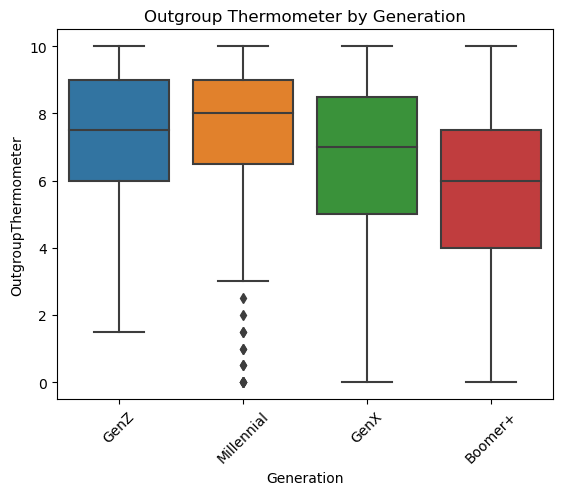

In [155]:
# Explore Relationships Between Feelings Towards Outgroups and Generation

sns.boxplot(x='Generation', y='OutgroupThermometer', data=data)
plt.title('Outgroup Thermometer by Generation')
plt.xticks(rotation=45)
plt.show()

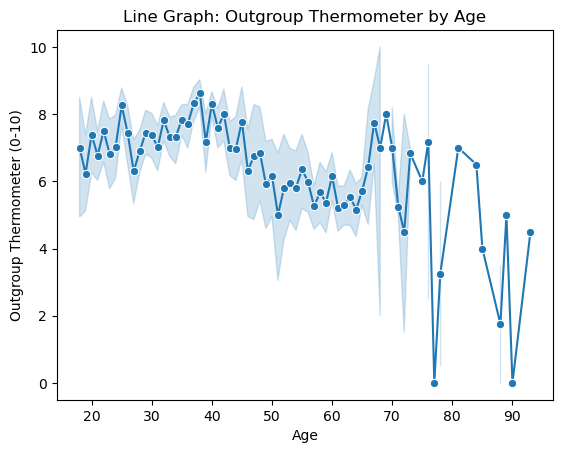

In [156]:
# Create a line plot: Outgroup Thermometer vs Age
sns.lineplot(x='Age', y='OutgroupThermometer', data=data, marker='o')

# Add labels and title
plt.title('Line Graph: Outgroup Thermometer by Age')
plt.xlabel('Age')
plt.ylabel('Outgroup Thermometer (0-10)')

# Show plot
plt.show()

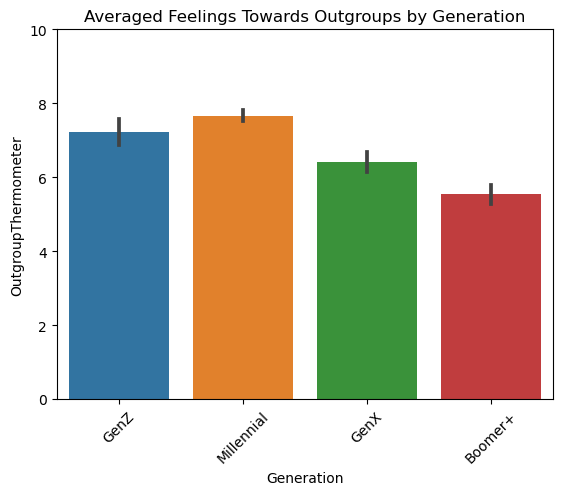

In [157]:
sns.barplot(x='Generation', y='OutgroupThermometer', data=data, estimator='mean')
plt.title('Averaged Feelings Towards Outgroups by Generation')
plt.xticks(rotation=45)
plt.ylim(0, 10)
plt.show()

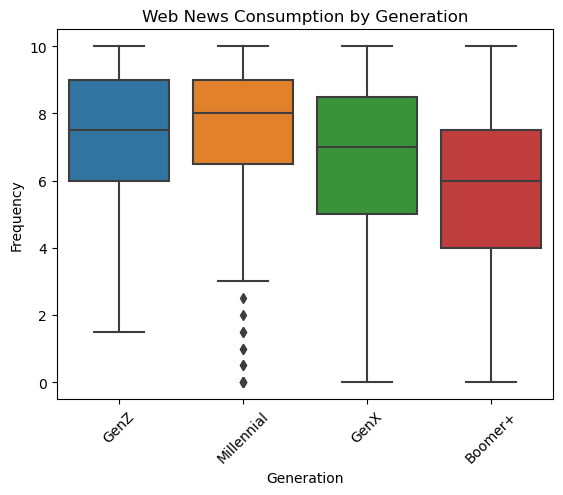

In [158]:
# Web News 

sns.boxplot(x='Generation', y='OutgroupThermometer', data=data)
plt.title('Web News Consumption by Generation')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

In [159]:
# Need to explore Millennial Outliers

# Filter data to include only Millennials
millennial_data = data[data['Generation'] == 'Millennial']

In [160]:
# Function to calculate IQR for a given column
def calculate_iqr(df, column):
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return Q1, Q3, IQR, lower_bound, upper_bound

# Calculate IQR for 'OutgroupThermometer' in the Millennial category
column = 'OutgroupThermometer'
Q1, Q3, IQR, lower_bound, upper_bound = calculate_iqr(millennial_data, column)

# Store results in a dictionary
iqr_results = {
    'Q1': Q1,
    'Q3': Q3,
    'IQR': IQR,
    'Lower Bound': lower_bound,
    'Upper Bound': upper_bound
}

# Convert results to DataFrame for better visualization
iqr_df = pd.DataFrame([iqr_results])

# Print the IQR results for 'OutgroupThermometer' in the Millennial category
print(iqr_df)

# Optionally: Find outliers
outliers = millennial_data[(millennial_data[column] < lower_bound) | (millennial_data[column] > upper_bound)]
print(f"Number of outliers in '{column}' for Millennials: {len(outliers)}")


    Q1   Q3  IQR  Lower Bound  Upper Bound
0  6.5  9.0  2.5         2.75        12.75
Number of outliers in 'OutgroupThermometer' for Millennials: 13


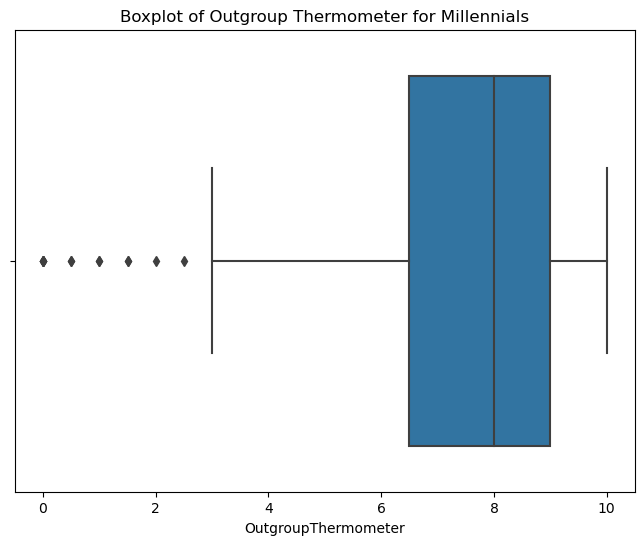

In [161]:
# Boxplot for 'OutgroupThermometer' in the Millennial category
plt.figure(figsize=(8, 6))
sns.boxplot(data=millennial_data, x='OutgroupThermometer')
plt.title('Boxplot of Outgroup Thermometer for Millennials')
plt.xlabel('OutgroupThermometer')
plt.show()

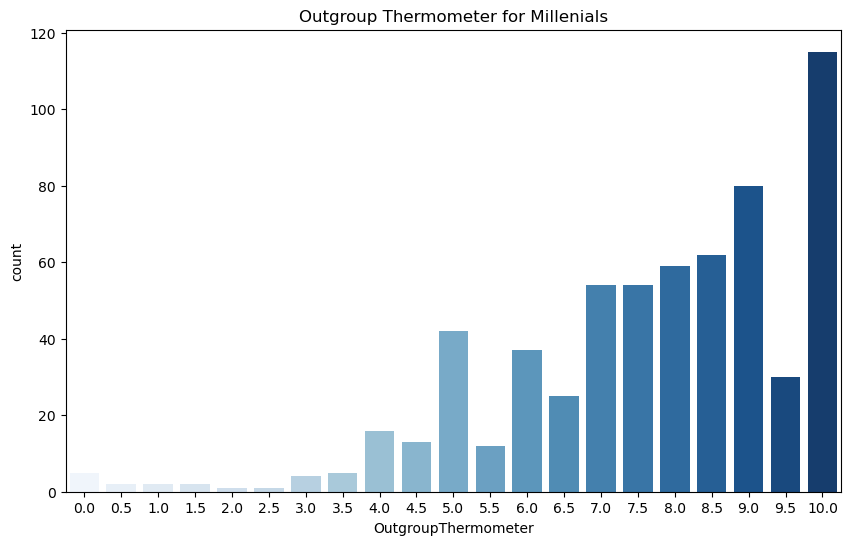

In [162]:
# Bar plot for Social Media News Consumption, displaying frequency of responses for Boomer +

plt.figure(figsize=(10, 6))
sns.countplot(x='OutgroupThermometer', data=millennial_data, palette='Blues')
plt.title('Outgroup Thermometer for Millenials')
plt.show()

In [163]:
data.groupby('Generation')['OutgroupThermometer'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
Generation,,,,,,,,
GenZ,123.0,7.2,2.0,1.5,6.0,7.5,9.0,10.0
Millennial,621.0,7.7,2.0,0.0,6.5,8.0,9.0,10.0
GenX,332.0,6.4,2.7,0.0,5.0,7.0,8.5,10.0
Boomer+,427.0,5.5,2.5,0.0,4.0,6.0,7.5,10.0


In [164]:
data.groupby('Generation')['OutgroupThermometer'].std().round(1)

Generation
GenZ          2.0
Millennial    2.0
GenX          2.7
Boomer+       2.5
Name: OutgroupThermometer, dtype: float64

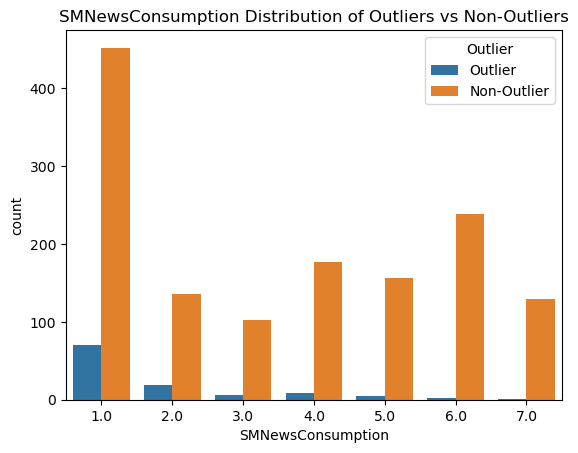

In [165]:
# Create a new column to label outliers vs non-outliers

data['Outlier'] = data['OutgroupThermometer'].apply(lambda x: 'Outlier' if (x < lower_bound or x > upper_bound) else 'Non-Outlier')
# Plot the distribution of gender for outliers vs non-outliers
sns.countplot(x='SMNewsConsumption', hue='Outlier', data=data)
plt.title('SMNewsConsumption Distribution of Outliers vs Non-Outliers')
plt.show()

In [166]:
# Extract rows of the entire dataset where the 'OutgroupThermometer' value is an outlier

outlier_rows = data[(data['Generation'] == 'Millennial') &
                    ((data['OutgroupThermometer'] < lower_bound) |
                     (data['OutgroupThermometer'] > upper_bound))]
# Check the outliers
print(outlier_rows.head())

       Country  ans_id  Gender  Age  V002bea  V002beb  V002at  V002de  V002es  \
10601        8       6       2   39      1.0      1.0     1.0     1.0     1.0   
10649        8      67       2   41      1.0      1.0     1.0     1.0     1.0   
10670        8      92       1   31      1.0      1.0     1.0     1.0     1.0   
10731        8     168       1   36      1.0      1.0     1.0     1.0     1.0   
10778        8     226       2   39      1.0      1.0     1.0     1.0     1.0   

       V002it  ...  Diploma2    Weging  Generation   weight  \
10601     1.0  ...         1  1.322459  Millennial  0.00161   
10649     1.0  ...         1  1.322459  Millennial  0.00161   
10670     1.0  ...         2  2.215758  Millennial  0.00161   
10731     1.0  ...         1  0.555021  Millennial  0.00161   
10778     1.0  ...         1  1.322459  Millennial  0.00161   

       OutgroupThermometer  BroadcastNewsConsumption  NewspaperConsumption  \
10601                  0.0                       1.0    

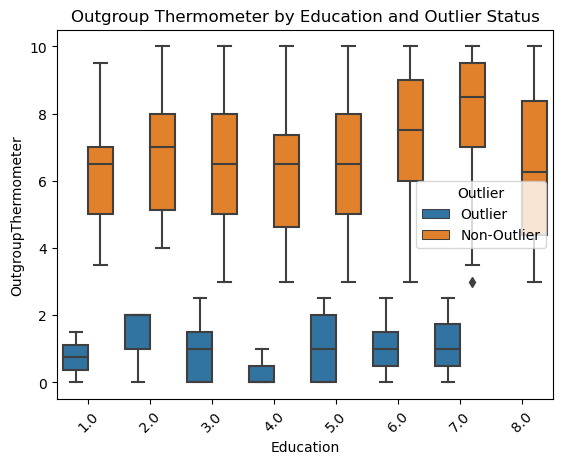

In [167]:
# Create a box plot to see the distribution of OutgroupThermometer for each education level
sns.boxplot(x='Education', y='OutgroupThermometer', hue='Outlier', data=data)
plt.title('Outgroup Thermometer by Education and Outlier Status')
plt.xticks(rotation=45)
plt.show()

In [168]:
millennial_data = data[data['Generation'] == 'Millennial']['OutgroupThermometer']

Q1 = np.percentile(millennial_data, 25)
Q3 = np.percentile(millennial_data, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = millennial_data[(millennial_data < lower_bound) | (millennial_data > upper_bound)]
print(outliers)


10601    0.0
10649    2.5
10670    0.5
10731    1.0
10778    0.0
10965    1.5
11025    0.5
11565    0.0
11656    0.0
11664    1.0
11771    0.0
11801    1.5
11936    2.0
Name: OutgroupThermometer, dtype: float64


In [169]:
# Extract rows of the entire dataset where the 'OutgroupThermometer' value is an outlier

outlier_rows = data[(data['Generation'] == 'Millennial') &
                    ((data['OutgroupThermometer'] < lower_bound) |
                     (data['OutgroupThermometer'] > upper_bound))]
# Check the outliers
print(outlier_rows.head())

       Country  ans_id  Gender  Age  V002bea  V002beb  V002at  V002de  V002es  \
10601        8       6       2   39      1.0      1.0     1.0     1.0     1.0   
10649        8      67       2   41      1.0      1.0     1.0     1.0     1.0   
10670        8      92       1   31      1.0      1.0     1.0     1.0     1.0   
10731        8     168       1   36      1.0      1.0     1.0     1.0     1.0   
10778        8     226       2   39      1.0      1.0     1.0     1.0     1.0   

       V002it  ...  Diploma2    Weging  Generation   weight  \
10601     1.0  ...         1  1.322459  Millennial  0.00161   
10649     1.0  ...         1  1.322459  Millennial  0.00161   
10670     1.0  ...         2  2.215758  Millennial  0.00161   
10731     1.0  ...         1  0.555021  Millennial  0.00161   
10778     1.0  ...         1  1.322459  Millennial  0.00161   

       OutgroupThermometer  BroadcastNewsConsumption  NewspaperConsumption  \
10601                  0.0                       1.0    

In [170]:
data

,Country,ans_id,Gender,Age,V002bea,V002beb,V002at,V002de,V002es,V002it,...,Diploma2,Weging,Generation,weight,OutgroupThermometer,BroadcastNewsConsumption,NewspaperConsumption,WebNewsConsumption,SMNewsConsumption,Outlier
10599,8,4,1,61,1.0,1.0,1.0,1.0,1.0,1.0,...,2,1.413913,Boomer+,0.002342,1.5,2.0,1.0,1.0,1.0,Outlier
10600,8,5,1,57,1.0,1.0,1.0,1.0,1.0,1.0,...,1,0.862578,GenX,0.003012,10.0,2.0,1.0,1.0,1.0,Non-Outlier
10601,8,6,2,39,1.0,1.0,1.0,1.0,1.0,1.0,...,1,1.322459,Millennial,0.001610,0.0,1.0,1.0,1.0,1.0,Outlier
10602,8,7,1,88,1.0,1.0,1.0,1.0,1.0,1.0,...,2,1.413913,Boomer+,0.002342,0.0,2.0,1.0,1.0,1.0,Outlier
10603,8,8,1,35,1.0,1.0,1.0,1.0,1.0,1.0,...,2,0.909775,Millennial,0.001610,6.0,3.0,3.0,3.0,4.0,Non-Outlier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12097,8,2114,2,29,1.0,1.0,1.0,1.0,1.0,1.0,...,1,0.748238,Millennial,0.001610,5.0,3.0,3.0,3.0,4.0,Non-Outlier
12098,8,2115,2,20,1.0,1.0,1.0,1.0,1.0,1.0,...,1,0.748238,GenZ,0.008130,5.0,4.0,2.0,2.0,1.0,Non-Outlier
12099,8,2116,2,20,1.0,1.0,1.0,1.0,1.0,1.0,...,1,0.748238,GenZ,0.008130,10.0,2.0,1.0,2.0,6.0,Non-Outlier
12100,8,2117,2,19,1.0,1.0,1.0,1.0,1.0,1.0,...,1,0.748238,GenZ,0.008130,6.0,3.0,3.0,4.0,3.0,Non-Outlier


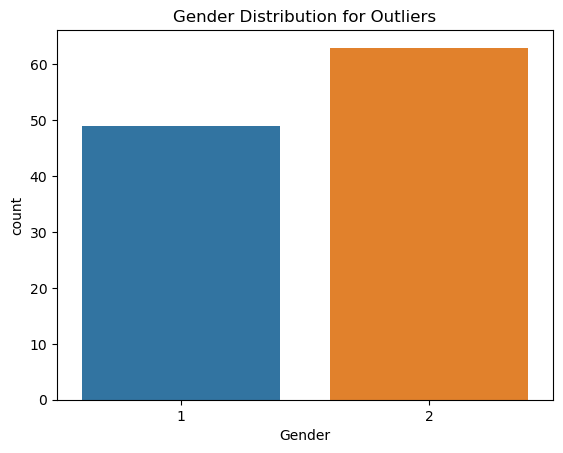

In [171]:
# Plot outliers separately
outlier_data = data[(data['OutgroupThermometer'] < lower_bound) |
                    (data['OutgroupThermometer'] > upper_bound)]
sns.countplot(x='Gender', data=outlier_data)
plt.title('Gender Distribution for Outliers')
plt.show()

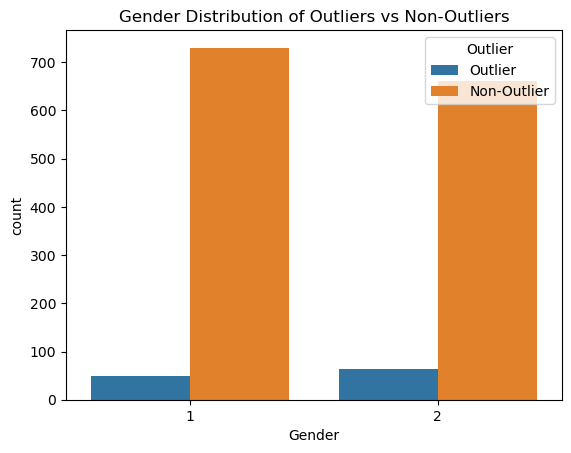

In [172]:
# Create a new column to label outliers vs non-outliers
data['Outlier'] = data['OutgroupThermometer'].apply(lambda x: 'Outlier' if (x < lower_bound or x > upper_bound) else 'Non-Outlier')
# Plot the distribution of gender for outliers vs non-outliers
sns.countplot(x='Gender', hue='Outlier', data=data)
plt.title('Gender Distribution of Outliers vs Non-Outliers')
plt.show()

In [173]:
data['OverallNewsConsumption'] = data[['BroadcastNewsConsumption', 'NewspaperConsumption', 'WebNewsConsumption', 'SMNewsConsumption']].mean(axis=1).round()

In [174]:
# Check the number of outliers based on IQR
outliers_count = data[(data['OutgroupThermometer'] < lower_bound) |
                      (data['OutgroupThermometer'] > upper_bound)].shape[0]
print(f"Number of outliers based on the IQR: {outliers_count}")

Number of outliers based on the IQR: 112


In [175]:
from scipy.stats import chi2_contingency
# Create a contingency table for Gender and Outlier status

OverallNewsConsumption_contingency = pd.crosstab(data['OverallNewsConsumption'], data['Outlier'])
# Perform the Chi-Square test
chi2, p_value, _, _ = chi2_contingency(OverallNewsConsumption_contingency)
print(f"Chi-Square Test for OverallNewsConsumption and Outlier Status: p-value = {p_value}")

Chi-Square Test for OverallNewsConsumption and Outlier Status: p-value = 2.7269357530789104e-15


In [176]:
outliers.value_counts()

0.0    5
0.5    2
1.0    2
1.5    2
2.5    1
2.0    1
Name: OutgroupThermometer, dtype: int64

In [177]:
# Now if I want to explore the relationship between Feeling Torwards Outgroups and News Consumption Habits I will need to normalise these amounts since they are on different scale.

In [178]:

data['OutgroupThermometer_normalised'] = (data['OutgroupThermometer'] - data['OutgroupThermometer'].min()) / (data['OutgroupThermometer'].max() - data['OutgroupThermometer'].min())
data['NewspaperConsumption_normalised'] = (data['NewspaperConsumption'] - data['NewspaperConsumption'].min()) / (data['NewspaperConsumption'].max() - data['NewspaperConsumption'].min())
data['WebNewsConsumption_normalised'] = (data['WebNewsConsumption'] - data['WebNewsConsumption'].min()) / (data['WebNewsConsumption'].max() - data['WebNewsConsumption'].min())
data['SMNewsConsumption_normalised'] = (data['SMNewsConsumption'] - data['SMNewsConsumption'].min()) / (data['SMNewsConsumption'].max() - data['SMNewsConsumption'].min())
data['BroadcastNewsConsumption_normalised'] = (data['BroadcastNewsConsumption'] - data['BroadcastNewsConsumption'].min()) / (data['BroadcastNewsConsumption'].max() - data['BroadcastNewsConsumption'].min())


In [179]:
print(data['OutgroupThermometer_normalised'].isna().sum())

0


In [180]:
data

,Country,ans_id,Gender,Age,V002bea,V002beb,V002at,V002de,V002es,V002it,...,NewspaperConsumption,WebNewsConsumption,SMNewsConsumption,Outlier,OverallNewsConsumption,OutgroupThermometer_normalised,NewspaperConsumption_normalised,WebNewsConsumption_normalised,SMNewsConsumption_normalised,BroadcastNewsConsumption_normalised
10599,8,4,1,61,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,Outlier,1.0,0.15,0.000000,0.000000,0.000000,0.166667
10600,8,5,1,57,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,Non-Outlier,1.0,1.00,0.000000,0.000000,0.000000,0.166667
10601,8,6,2,39,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,Outlier,1.0,0.00,0.000000,0.000000,0.000000,0.000000
10602,8,7,1,88,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,Outlier,1.0,0.00,0.000000,0.000000,0.000000,0.166667
10603,8,8,1,35,1.0,1.0,1.0,1.0,1.0,1.0,...,3.0,3.0,4.0,Non-Outlier,3.0,0.60,0.333333,0.333333,0.500000,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12097,8,2114,2,29,1.0,1.0,1.0,1.0,1.0,1.0,...,3.0,3.0,4.0,Non-Outlier,3.0,0.50,0.333333,0.333333,0.500000,0.333333
12098,8,2115,2,20,1.0,1.0,1.0,1.0,1.0,1.0,...,2.0,2.0,1.0,Non-Outlier,2.0,0.50,0.166667,0.166667,0.000000,0.500000
12099,8,2116,2,20,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,2.0,6.0,Non-Outlier,3.0,1.00,0.000000,0.166667,0.833333,0.166667
12100,8,2117,2,19,1.0,1.0,1.0,1.0,1.0,1.0,...,3.0,4.0,3.0,Non-Outlier,3.0,0.60,0.333333,0.500000,0.333333,0.333333


In [181]:
# Exploring Relationships Between Feelings Towards Outgroups and Consumption Habits

/opt/conda/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


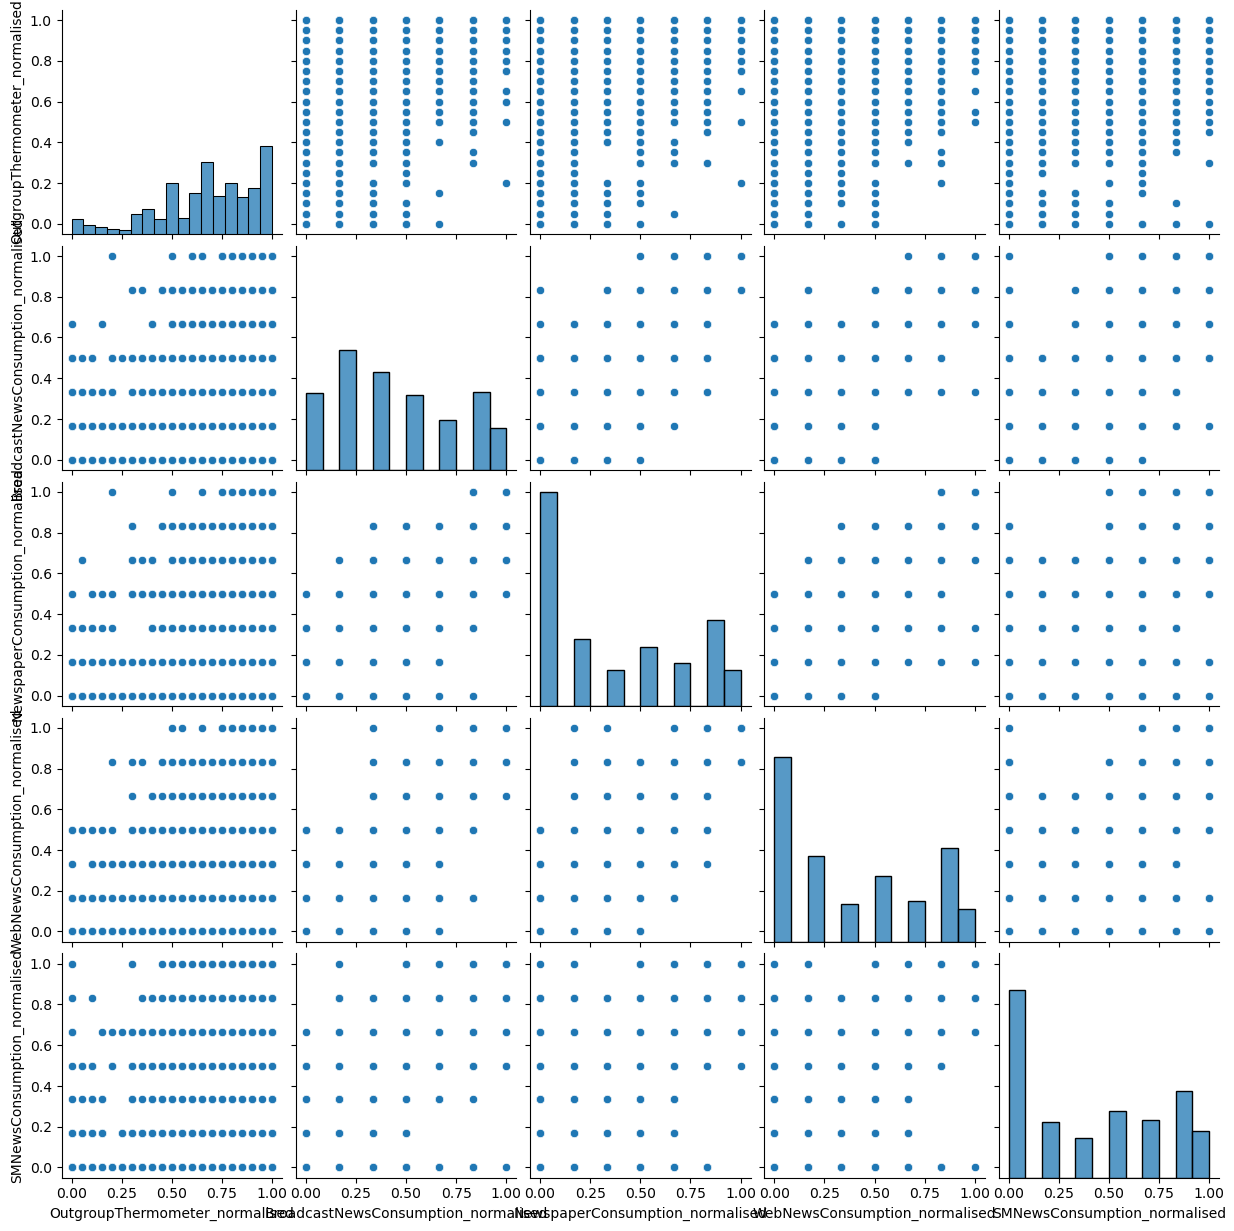

In [182]:
sns.pairplot(data[['OutgroupThermometer_normalised', 'BroadcastNewsConsumption_normalised', 'NewspaperConsumption_normalised', 'WebNewsConsumption_normalised', 'SMNewsConsumption_normalised']])
plt.show()

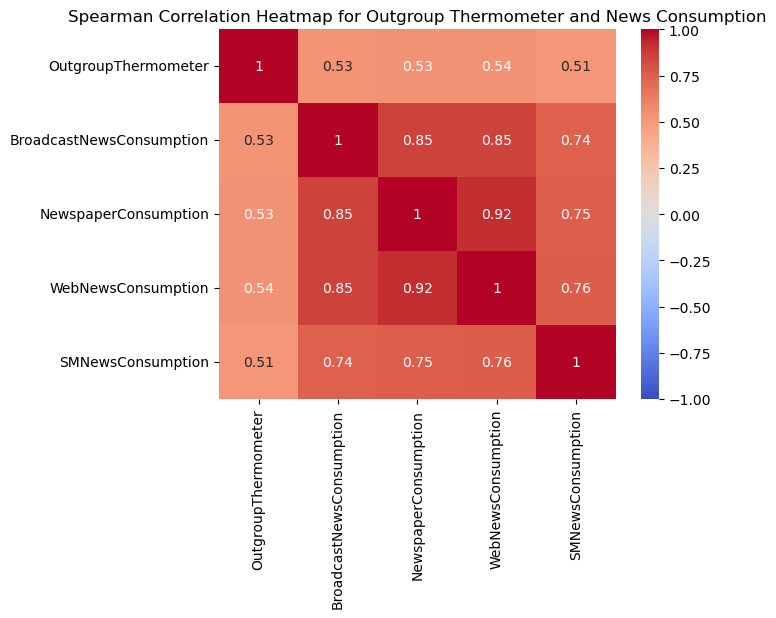

In [183]:
# Calculate the Spearman correlation matrix
corr_matrix = data[['OutgroupThermometer', 
                     'BroadcastNewsConsumption', 
                     'NewspaperConsumption', 
                     'WebNewsConsumption', 
                     'SMNewsConsumption']].corr(method='spearman')

# Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

# Set the title for the heatmap
plt.title('Spearman Correlation Heatmap for Outgroup Thermometer and News Consumption')

# Display the heatmap
plt.show()


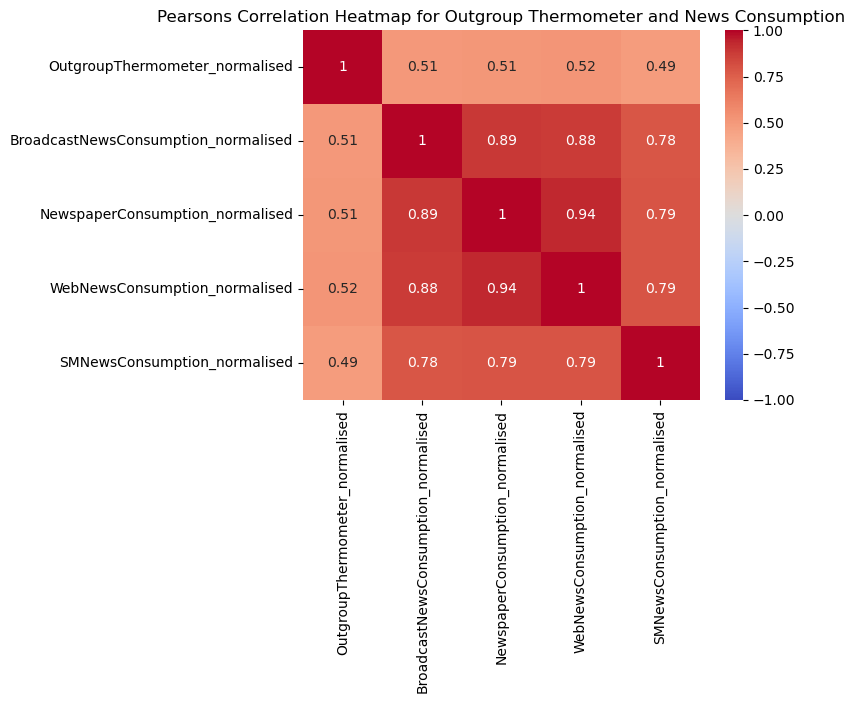

In [184]:
corr_matrix = data[['OutgroupThermometer_normalised', 
                     'BroadcastNewsConsumption_normalised', 
                     'NewspaperConsumption_normalised', 
                     'WebNewsConsumption_normalised', 
                     'SMNewsConsumption_normalised']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearsons Correlation Heatmap for Outgroup Thermometer and News Consumption')
plt.show()

In [185]:
# The Pearson correlation coefficient measures the strength and direction of the linear relationship between two continuous variables. 
# It tells you how strongly two variables are related in a linear way.
# Range: The Pearson correlation ranges from -1 to +1.
# +1: Perfect positive linear correlation (as one variable increases, the other increases).
# 0: No linear correlation (the variables do not have a linear relationship).
# -1: Perfect negative linear correlation (as one variable increases, the other decreases).



corr1, p_value1 = pearsonr(data['OutgroupThermometer_normalised'], data['BroadcastNewsConsumption_normalised'])
corr2, p_value2 = pearsonr(data['OutgroupThermometer_normalised'], data['NewspaperConsumption_normalised'])
corr3, p_value3 = pearsonr(data['OutgroupThermometer_normalised'], data['WebNewsConsumption_normalised'])
corr4, p_value4 = pearsonr(data['OutgroupThermometer_normalised'], data['SMNewsConsumption_normalised'])

# Output the correlation coefficient and p-value
print ("Outgroup Thermometer x Broadcast News Consumption")
print(f"Pearson correlation coefficient: {corr1}")
print(f"P-value: {p_value1}")
print("-----------")

print ("Outgroup Thermometer x Newspaper Consumption")
print(f"Pearson correlation coefficient: {corr2}")
print(f"P-value: {p_value2}")
print("-----------")

print ("Outgroup Thermometer x Web News Consumption")
print(f"Pearson correlation coefficient: {corr3}")
print(f"P-value: {p_value3}")
print("-----------")

print ("Outgroup Thermometer x Social Media News Consumption")
print(f"Pearson correlation coefficient: {corr4}")
print(f"P-value: {p_value4}")
print("-----------")


Outgroup Thermometer x Broadcast News Consumption
Pearson correlation coefficient: 0.5075487827631776
P-value: 3.3008845634485968e-99
-----------
Outgroup Thermometer x Newspaper Consumption
Pearson correlation coefficient: 0.509541963410445
P-value: 4.223622041785431e-100
-----------
Outgroup Thermometer x Web News Consumption
Pearson correlation coefficient: 0.5171475545961283
P-value: 1.4567620084976642e-103
-----------
Outgroup Thermometer x Social Media News Consumption
Pearson correlation coefficient: 0.48642952193006433
P-value: 4.220677981140164e-90
-----------


In [186]:
# Spearman Correlation to see if non-linear relationship.
# For both Pearson and Spearman Correlation:
# Correlation Coefficient: The closer to 1 or -1, the stronger the relationship:
# 1: Perfect positive correlation.
# -1: Perfect negative correlation.
# 0: No correlation.
# A positive value means that as one variable increases, the other tends to increase as well (for positive correlations).
# A negative value means that as one variable increases, the other tends to decrease (for negative correlations).
# p-value: The p-value tests the null hypothesis (that there is no correlation).
# A low p-value (typically less than 0.05) indicates that the correlation is statistically significant. This means that the relationship between the variables is unlikely to have occurred by chance.
# A high p-value (greater than 0.05) suggests that any observed correlation is likely due to random chance, and thus we would fail to reject the null hypothesis.

corr5, p_value5 = spearmanr(data['OutgroupThermometer'], data['BroadcastNewsConsumption'])
corr6, p_value6 = spearmanr(data['OutgroupThermometer'], data['NewspaperConsumption'])
corr7, p_value7 = spearmanr(data['OutgroupThermometer'], data['WebNewsConsumption'])
corr8, p_value8 = spearmanr(data['OutgroupThermometer'], data['SMNewsConsumption'])


print(f"Spearman correlation for Outgroup Thermometer x Broadcast News Consumption: {corr5}, p-value: {p_value5}")
print(f"Spearman correlation for Outgroup Thermometer x Newspaper Consumption: {corr6}, p-value: {p_value6}")
print(f"Spearman correlation for Outgroup Thermometer x Web News Consumption: {corr7}, p-value: {p_value7}")
print(f"Spearman correlation for Outgroup Thermometer x Social Media News Consumption: {corr8}, p-value: {p_value8}")

Spearman correlation for Outgroup Thermometer x Broadcast News Consumption: 0.5250024371153184, p-value: 3.120184194988986e-107
Spearman correlation for Outgroup Thermometer x Newspaper Consumption: 0.5338798350276833, p-value: 1.6965975554356722e-111
Spearman correlation for Outgroup Thermometer x Web News Consumption: 0.5352027109466542, p-value: 3.8295091679809607e-112
Spearman correlation for Outgroup Thermometer x Social Media News Consumption: 0.5099855527241485, p-value: 2.667778162037287e-100


In [187]:
# These weird p-values are actually very very small numbers, close to 0. This means that the correlation is very strong, and the relationship between variables is not due to random chance.
# All of the Spearman Correlations are above 0.5, which means there is a moderate postiive correlation. 

In [188]:
# Weighting for Generation due to disproportionate weighting within categories. 

# Calculate the count of each generation group
gen_counts = data['Generation'].value_counts()

# Calculate weights as the inverse of the count (smaller groups get larger weights)
weights = 1 / gen_counts

# Map the weights to the original dataset based on 'Generation'
data['weight'] = data['Generation'].map(weights)

# Verify that weights have been applied correctly
print(data[['Generation', 'weight']].head())

       Generation    weight
10599     Boomer+  0.002342
10600        GenX  0.003012
10601  Millennial  0.001610
10602     Boomer+  0.002342
10603  Millennial  0.001610


In [189]:
#Name and categorise genders 

# Replace the values 1, 2 and 3 in the 'Gender' column with 'Male', 'Female' and 'Other' 

data['Gender'] = data['Gender'].replace({1: 'Male', 2: 'Female', }) 

#Name and categorise marital status 
data['MaritalSt'] = data['MaritalSt'].replace({1: 'Unmarried', 2: 'Cohabiting', 3: 'Married', 4: 'Divorced', 5: 'Widowed'})

# Urban Density 
data['UrbanDensity'] = data['UrbanDensity'].replace({1: 'Countryside', 2: 'Small town', 3: 'Small city', 4: 'Suburb', 5: 'Large city'})


In [190]:
data

,Country,ans_id,Gender,Age,V002bea,V002beb,V002at,V002de,V002es,V002it,...,NewspaperConsumption,WebNewsConsumption,SMNewsConsumption,Outlier,OverallNewsConsumption,OutgroupThermometer_normalised,NewspaperConsumption_normalised,WebNewsConsumption_normalised,SMNewsConsumption_normalised,BroadcastNewsConsumption_normalised
10599,8,4,Male,61,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,Outlier,1.0,0.15,0.000000,0.000000,0.000000,0.166667
10600,8,5,Male,57,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,Non-Outlier,1.0,1.00,0.000000,0.000000,0.000000,0.166667
10601,8,6,Female,39,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,Outlier,1.0,0.00,0.000000,0.000000,0.000000,0.000000
10602,8,7,Male,88,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,Outlier,1.0,0.00,0.000000,0.000000,0.000000,0.166667
10603,8,8,Male,35,1.0,1.0,1.0,1.0,1.0,1.0,...,3.0,3.0,4.0,Non-Outlier,3.0,0.60,0.333333,0.333333,0.500000,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12097,8,2114,Female,29,1.0,1.0,1.0,1.0,1.0,1.0,...,3.0,3.0,4.0,Non-Outlier,3.0,0.50,0.333333,0.333333,0.500000,0.333333
12098,8,2115,Female,20,1.0,1.0,1.0,1.0,1.0,1.0,...,2.0,2.0,1.0,Non-Outlier,2.0,0.50,0.166667,0.166667,0.000000,0.500000
12099,8,2116,Female,20,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,2.0,6.0,Non-Outlier,3.0,1.00,0.000000,0.166667,0.833333,0.166667
12100,8,2117,Female,19,1.0,1.0,1.0,1.0,1.0,1.0,...,3.0,4.0,3.0,Non-Outlier,3.0,0.60,0.333333,0.500000,0.333333,0.333333


In [191]:
# Handle NaN Values for Income

data['Income'] = data['Income'].replace(13, np.nan)
data['Income'] = data['Income'].replace(98, np.nan)
data['Income'] = data['Income'].replace(99, np.nan)


In [192]:
# Step 1: Map the income categories to income ranges
# We will map the ordinal categories to the median income for each range
income_mapping = {
    1: 500,       # Lt $1000
    2: 2000,      # $1000 to 2999
    3: 3500,      # $3000 to 3999
    4: 4500,      # $4000 to 4999
    5: 5500,      # $5000 to 5999
    6: 6500,      # $6000 to 6999
    7: 7500,      # $7000 to 7999
    8: 9000,      # $8000 to 9999
    9: 12500,     # $10000 - 14999
    10: 17500,    # $15000 - 19999
    11: 22500,    # $20000 - 24999
    12: 27500,    # $25000 or more
}

# Step 2: Map the Income column
data['Income_Numeric'] = data['Income'].map(income_mapping)

# Step 3: Handle missing values (Refused, Don't Know, No Answer)
# We'll replace NaN values with the median income, but you can choose to drop rows if needed
median_income = data['Income_Numeric'].median()
data.dropna(subset=['Income_Numeric'], inplace=True)

# Step 4: Check the result
data['Income_Numeric']

# If you're using this variable in a regression model, now you can use 'Income_Numeric'.


10600    22500.0
10602     2000.0
10603    27500.0
10604    22500.0
10605      500.0
          ...   
12096     2000.0
12098     2000.0
12099    22500.0
12100      500.0
12101    27500.0
Name: Income_Numeric, Length: 1347, dtype: float64

In [193]:
# Create an instance of MinMaxScaler
scaler = MinMaxScaler()

# Normalize the 'Income_Numeric' column
data['Income_normalized'] = scaler.fit_transform(data[['Income_Numeric']])

# Check the result
print(data[['Income_Numeric', 'Income_normalized']].head())


       Income_Numeric  Income_normalized
10600         22500.0           0.814815
10602          2000.0           0.055556
10603         27500.0           1.000000
10604         22500.0           0.814815
10605           500.0           0.000000


In [194]:
data

,Country,ans_id,Gender,Age,V002bea,V002beb,V002at,V002de,V002es,V002it,...,SMNewsConsumption,Outlier,OverallNewsConsumption,OutgroupThermometer_normalised,NewspaperConsumption_normalised,WebNewsConsumption_normalised,SMNewsConsumption_normalised,BroadcastNewsConsumption_normalised,Income_Numeric,Income_normalized
10600,8,5,Male,57,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,Non-Outlier,1.0,1.00,0.000000,0.000000,0.000000,0.166667,22500.0,0.814815
10602,8,7,Male,88,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,Outlier,1.0,0.00,0.000000,0.000000,0.000000,0.166667,2000.0,0.055556
10603,8,8,Male,35,1.0,1.0,1.0,1.0,1.0,1.0,...,4.0,Non-Outlier,3.0,0.60,0.333333,0.333333,0.500000,0.333333,27500.0,1.000000
10604,8,10,Female,34,1.0,1.0,1.0,1.0,1.0,1.0,...,7.0,Non-Outlier,7.0,0.90,1.000000,1.000000,1.000000,1.000000,22500.0,0.814815
10605,8,12,Female,38,1.0,1.0,1.0,1.0,1.0,1.0,...,7.0,Non-Outlier,7.0,0.90,0.833333,1.000000,1.000000,1.000000,500.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12096,8,2113,Female,21,1.0,1.0,1.0,1.0,1.0,1.0,...,4.0,Non-Outlier,3.0,0.65,0.333333,0.333333,0.500000,0.333333,2000.0,0.055556
12098,8,2115,Female,20,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,Non-Outlier,2.0,0.50,0.166667,0.166667,0.000000,0.500000,2000.0,0.055556
12099,8,2116,Female,20,1.0,1.0,1.0,1.0,1.0,1.0,...,6.0,Non-Outlier,3.0,1.00,0.000000,0.166667,0.833333,0.166667,22500.0,0.814815
12100,8,2117,Female,19,1.0,1.0,1.0,1.0,1.0,1.0,...,3.0,Non-Outlier,3.0,0.60,0.333333,0.500000,0.333333,0.333333,500.0,0.000000


In [195]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Apply label encoding to 'Generation' and store it in a new column 'Generation_encoded'
data['Generation_encoded'] = label_encoder.fit_transform(data['Generation'])

# Apply label encoding to 'MaritalSt' and store it in a new column 'MaritalSt_encoded'
data['MaritalSt_encoded'] = label_encoder.fit_transform(data['MaritalSt'])

# Apply label encoding to 'UrbanDensity' and store it in a new column 'UrbanDensity_encoded'
data['UrbanDensity_encoded'] = label_encoder.fit_transform(data['UrbanDensity'])

# Apply label encoding to 'Gender' and store it in a new column 'Gender_encoded'
data['Gender_encoded'] = label_encoder.fit_transform(data['Gender'])

# Verify that the original columns are still intact
print(data[['Generation', 'Generation_encoded', 'MaritalSt', 'MaritalSt_encoded', 
            'UrbanDensity', 'UrbanDensity_encoded', 'Gender', 'Gender_encoded']].head())


       Generation  Generation_encoded  MaritalSt  MaritalSt_encoded  \
10600        GenX                   1  Unmarried                  3   
10602     Boomer+                   0  Unmarried                  3   
10603  Millennial                   3  Unmarried                  3   
10604  Millennial                   3    Married                  2   
10605  Millennial                   3    Married                  2   

      UrbanDensity  UrbanDensity_encoded  Gender  Gender_encoded  
10600   Large city                     1    Male               1  
10602   Large city                     1    Male               1  
10603       Suburb                     4    Male               1  
10604   Large city                     1  Female               0  
10605   Large city                     1  Female               0  


In [196]:
data



,Country,ans_id,Gender,Age,V002bea,V002beb,V002at,V002de,V002es,V002it,...,NewspaperConsumption_normalised,WebNewsConsumption_normalised,SMNewsConsumption_normalised,BroadcastNewsConsumption_normalised,Income_Numeric,Income_normalized,Generation_encoded,MaritalSt_encoded,UrbanDensity_encoded,Gender_encoded
10600,8,5,Male,57,1.0,1.0,1.0,1.0,1.0,1.0,...,0.000000,0.000000,0.000000,0.166667,22500.0,0.814815,1,3,1,1
10602,8,7,Male,88,1.0,1.0,1.0,1.0,1.0,1.0,...,0.000000,0.000000,0.000000,0.166667,2000.0,0.055556,0,3,1,1
10603,8,8,Male,35,1.0,1.0,1.0,1.0,1.0,1.0,...,0.333333,0.333333,0.500000,0.333333,27500.0,1.000000,3,3,4,1
10604,8,10,Female,34,1.0,1.0,1.0,1.0,1.0,1.0,...,1.000000,1.000000,1.000000,1.000000,22500.0,0.814815,3,2,1,0
10605,8,12,Female,38,1.0,1.0,1.0,1.0,1.0,1.0,...,0.833333,1.000000,1.000000,1.000000,500.0,0.000000,3,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12096,8,2113,Female,21,1.0,1.0,1.0,1.0,1.0,1.0,...,0.333333,0.333333,0.500000,0.333333,2000.0,0.055556,2,3,0,0
12098,8,2115,Female,20,1.0,1.0,1.0,1.0,1.0,1.0,...,0.166667,0.166667,0.000000,0.500000,2000.0,0.055556,2,3,3,0
12099,8,2116,Female,20,1.0,1.0,1.0,1.0,1.0,1.0,...,0.000000,0.166667,0.833333,0.166667,22500.0,0.814815,2,3,2,0
12100,8,2117,Female,19,1.0,1.0,1.0,1.0,1.0,1.0,...,0.333333,0.500000,0.333333,0.333333,500.0,0.000000,2,3,4,0


In [197]:
print(data[['Generation', 'Generation_encoded']].head())

       Generation  Generation_encoded
10600        GenX                   1
10602     Boomer+                   0
10603  Millennial                   3
10604  Millennial                   3
10605  Millennial                   3


In [198]:
# Ensure that the 'Generation' column is kept in its original form while adding one-hot encoded columns

# One-Hot Encoding for 'Gender', 'MaritalSt', 'UrbanDensity', and 'Generation'
data = pd.get_dummies(data, 
                       columns=['Gender', 'MaritalSt', 'UrbanDensity', 'Generation'], 
                       drop_first=False, 
                       prefix=['Gender', 'MaritalSt', 'UrbanDensity', 'Generation'])

# Verify that 'Generation' column is preserved and new columns are added
print(data.columns)


Index(['Country', 'ans_id', 'Age', 'V002bea', 'V002beb', 'V002at', 'V002de',
       'V002es', 'V002it', 'V002hu',
       ...
       'MaritalSt_Widowed', 'UrbanDensity_Countryside',
       'UrbanDensity_Large city', 'UrbanDensity_Small city',
       'UrbanDensity_Small town', 'UrbanDensity_Suburb', 'Generation_GenZ',
       'Generation_Millennial', 'Generation_GenX', 'Generation_Boomer+'],
      dtype='object', length=667)


In [199]:
# Creating smaller dataset for ML Models 
newsclus = data[['Gender_Male', 'Gender_Female', 'Generation_encoded', 'OutgroupThermometer_normalised', 'NewspaperConsumption_normalised', 'WebNewsConsumption_normalised', 'SMNewsConsumption_normalised', 'BroadcastNewsConsumption_normalised', 'MaritalSt_Cohabiting', 'MaritalSt_Divorced', 'MaritalSt_Married', 'MaritalSt_Unmarried', 'MaritalSt_Widowed', 'UrbanDensity_Countryside', 'UrbanDensity_Large city', 'UrbanDensity_Small town', 'UrbanDensity_Suburb', 'Income_normalized'  ]]

In [203]:
# Define a range of possible 'k' values (number of clusters) to test
kvals = np.arange(2, 10)  # Values of 'k' from 2 to 9
scores = []               # Empty list to store silhouette scores for each 'k'
distsq = []               # Empty list to store inertia (sum of squared distances) for each 'k'

# Loop over each value of 'k' to test different numbers of clusters
for k in kvals:
    # Initialize a KMeans model with the current 'k' clusters
    clusters = clus.KMeans(n_clusters=k, n_init="auto", random_state=42)  # n_init="auto" chooses best init method

    # Fit the KMeans model on the data, selecting only specific features
    clus_pred = clusters.fit(data[['OutgroupThermometer_normalised', 
              'NewspaperConsumption_normalised', 
              'WebNewsConsumption_normalised', 
              'SMNewsConsumption_normalised', 
              'BroadcastNewsConsumption_normalised', 
              'Generation_encoded', 
              'Gender_Male', 'Gender_Female', 
              'MaritalSt_Cohabiting', 'MaritalSt_Divorced', 
              'MaritalSt_Married', 'MaritalSt_Unmarried', 
              'MaritalSt_Widowed', 'UrbanDensity_Countryside', 
              'UrbanDensity_Large city', 'UrbanDensity_Small town', 'UrbanDensity_Suburb', 'Income_normalized']])

    # Calculate the silhouette score, which measures how well the clusters are separated
    score = metrics.silhouette_score(data[['OutgroupThermometer_normalised', 
                                            'NewspaperConsumption_normalised', 
                                            'WebNewsConsumption_normalised', 
                                            'SMNewsConsumption_normalised', 
                                            'BroadcastNewsConsumption_normalised', 
                                            'Generation_encoded', 
                                            'Gender_Male', 'Gender_Female', 
                                            'MaritalSt_Cohabiting', 'MaritalSt_Divorced', 
                                            'MaritalSt_Married', 'MaritalSt_Unmarried', 
                                            'MaritalSt_Widowed', 'UrbanDensity_Countryside', 
                                            'UrbanDensity_Large city', 'UrbanDensity_Small town', 
                                            'UrbanDensity_Suburb', 'Income_normalized']], 
                            clus_pred.labels_)

    print('Silhouette score for k =', k, ':', score)  # Print silhouette score for the current 'k'
    scores.append(score)    # Add the score to the scores list

    # Print and save the inertia value, which is the sum of squared distances to the nearest cluster center
    print('Inertia (sum of squared distances to the nearest cluster center) for k =', k, ':', clus_pred.inertia_)
    distsq.append(clus_pred.inertia_)  # Add inertia to distsq list
    
    print('---------------------------------')


Silhouette score for k = 2 : 0.35198390353881764
Inertia (sum of squared distances to the nearest cluster center) for k = 2 : 3211.3365737161375
---------------------------------
Silhouette score for k = 3 : 0.27331565681261355
Inertia (sum of squared distances to the nearest cluster center) for k = 3 : 2846.2649010114283
---------------------------------
Silhouette score for k = 4 : 0.22707863717981755
Inertia (sum of squared distances to the nearest cluster center) for k = 4 : 2652.447177855409
---------------------------------
Silhouette score for k = 5 : 0.2577732767898246
Inertia (sum of squared distances to the nearest cluster center) for k = 5 : 2186.8940210304486
---------------------------------
Silhouette score for k = 6 : 0.2549387922316762
Inertia (sum of squared distances to the nearest cluster center) for k = 6 : 2028.038886644876
---------------------------------
Silhouette score for k = 7 : 0.24995434346637066
Inertia (sum of squared distances to the nearest cluster cen

/opt/conda/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/tmp/ipykernel_252/4067099677.py:25: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  print(data.groupby('Cluster').mean())


         Country       ans_id        Age  V002bea  V002beb  V002at  V002de  \
Cluster                                                                      
0            8.0  1003.849502  50.358209      1.0      1.0     1.0     1.0   
1            8.0   970.637201  37.116022      1.0      1.0     1.0     1.0   

         V002es  V002it  V002hu  ...  MaritalSt_Widowed  \
Cluster                          ...                      
0           1.0     1.0     1.0  ...           0.033582   
1           1.0     1.0     1.0  ...           0.000000   

         UrbanDensity_Countryside  UrbanDensity_Large city  \
Cluster                                                      
0                        0.119403                 0.143035   
1                        0.099448                 0.626151   

         UrbanDensity_Small city  UrbanDensity_Small town  \
Cluster                                                     
0                       0.130597                 0.201493   
1                 

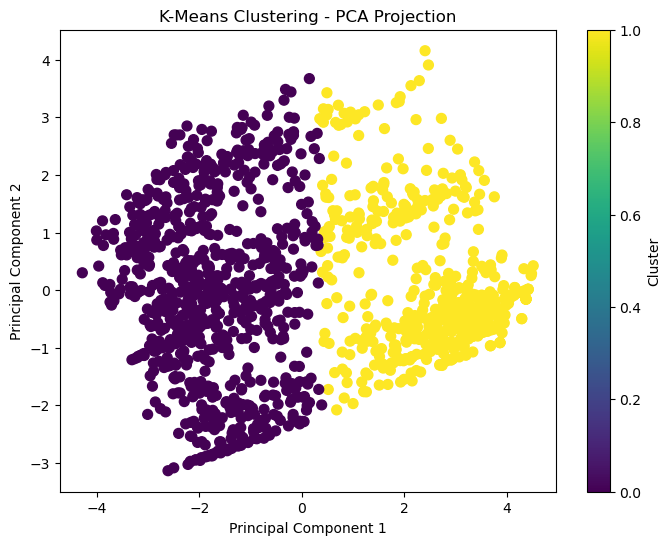

In [202]:
# Clustering

# Selecting features of interest (news consumption, attitudes, and demographic variables)
X = data[['OutgroupThermometer_normalised', 
              'NewspaperConsumption_normalised', 
              'WebNewsConsumption_normalised', 
              'SMNewsConsumption_normalised', 
              'BroadcastNewsConsumption_normalised', 
              'Generation_encoded', 
              'Gender_Male', 'Gender_Female', 
          'MaritalSt_Cohabiting', 'MaritalSt_Divorced', 
          'MaritalSt_Married', 'MaritalSt_Unmarried', 
          'MaritalSt_Widowed', 'UrbanDensity_Countryside', 
          'UrbanDensity_Large city', 'UrbanDensity_Small town', 'UrbanDensity_Suburb', 'Income_normalized' ]]

# Standardizing the data before clustering (important for ML models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans Clustering (e.g., 3 clusters)
kmeans = KMeans(n_clusters=2, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

# Explore the clustering results
print(data.groupby('Cluster').mean())

# Step 4: Visualize clusters (using PCA or t-SNE as described earlier)
# Example of PCA visualization:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data['Cluster'], cmap='viridis', s=50)
plt.title('K-Means Clustering - PCA Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [204]:
# Assign the cluster labels to the data
data['Cluster'] = kmeans.labels_

# Group by cluster and calculate the mean and standard deviation of attitudes towards outgroups
cluster_summary = data.groupby('Cluster')['OutgroupThermometer_normalised'].agg(['mean', 'std', 'count']).round(3)

# Print the summary statistics for each cluster
print(cluster_summary)


          mean    std  count
Cluster                     
0        0.585  0.245    804
1        0.838  0.152    543


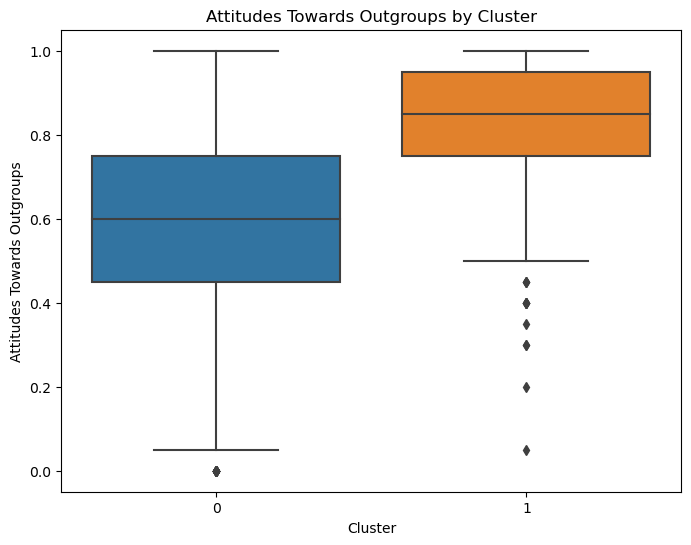

In [205]:
# Create a boxplot to visualize the distribution of attitudes towards outgroups across clusters
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cluster', y='OutgroupThermometer_normalised', data=data)
plt.title('Attitudes Towards Outgroups by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Attitudes Towards Outgroups')
plt.show()

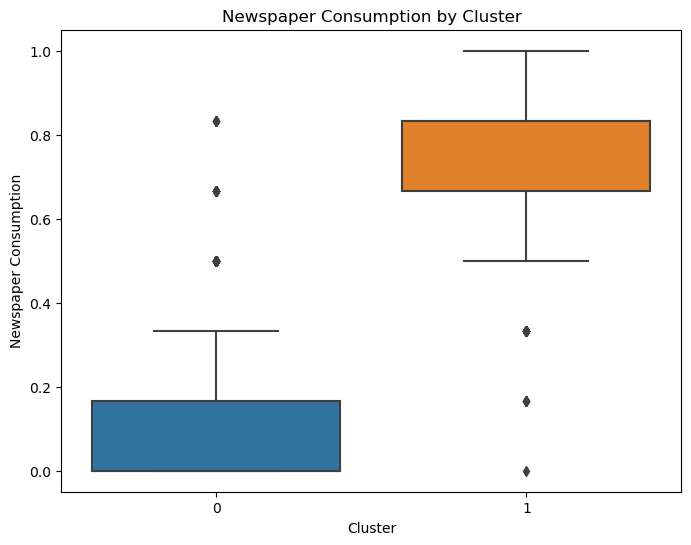

In [206]:
# Create a boxplot to visualize news consumption habits across clusters
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cluster', y='NewspaperConsumption_normalised', data=data)
plt.title('Newspaper Consumption by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Newspaper Consumption')
plt.show()


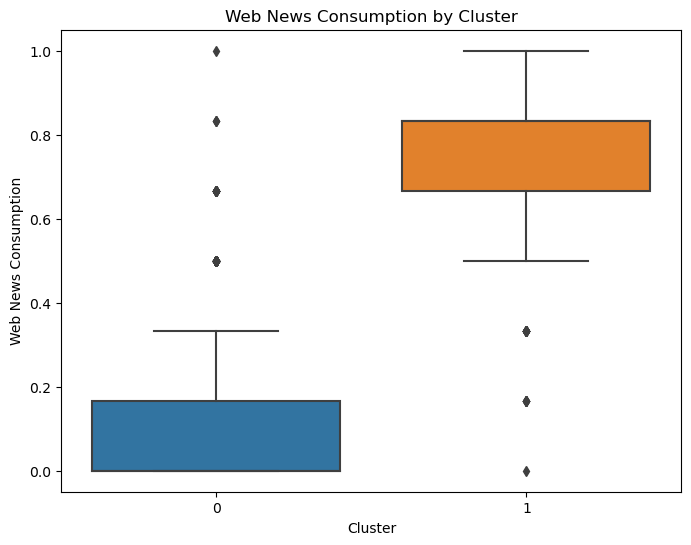

In [207]:
# Create a boxplot to visualize news consumption habits across clusters
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cluster', y='WebNewsConsumption_normalised', data=data)
plt.title('Web News Consumption by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Web News Consumption')
plt.show()

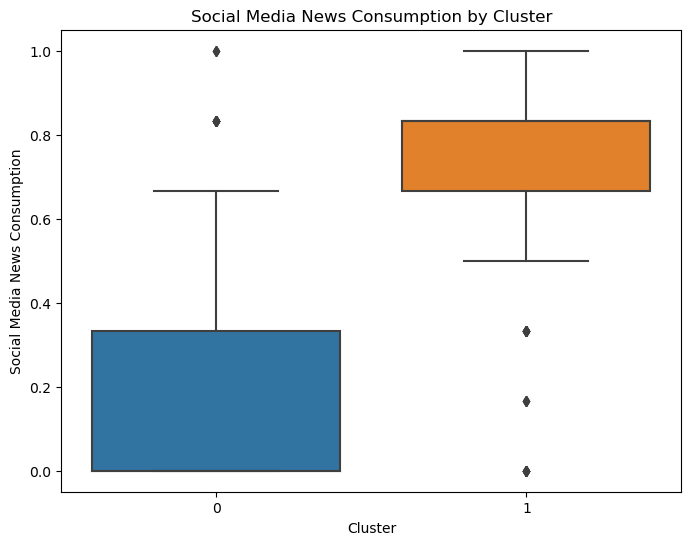

In [208]:
# Create a boxplot to visualize news consumption habits across clusters
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cluster', y='SMNewsConsumption_normalised', data=data)
plt.title('Social Media News Consumption by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Social Media News Consumption')
plt.show()

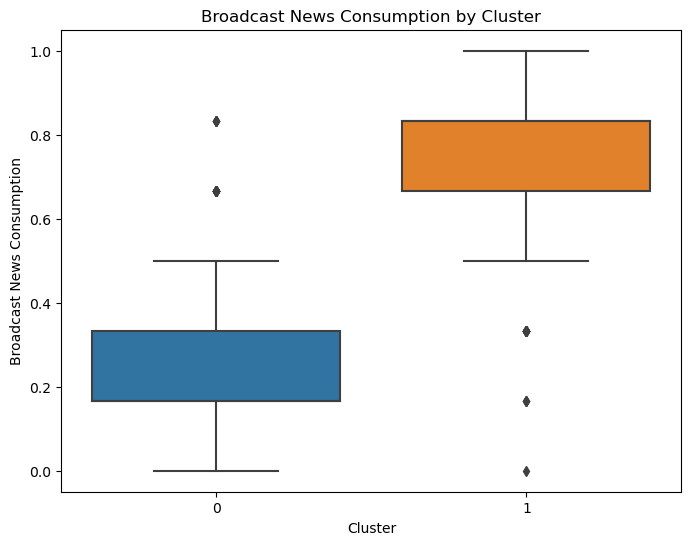

In [209]:
# Create a boxplot to visualize news consumption habits across clusters
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cluster', y='BroadcastNewsConsumption_normalised', data=data)
plt.title('Broadcast News Consumption by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Broadcast News Consumption')
plt.show()


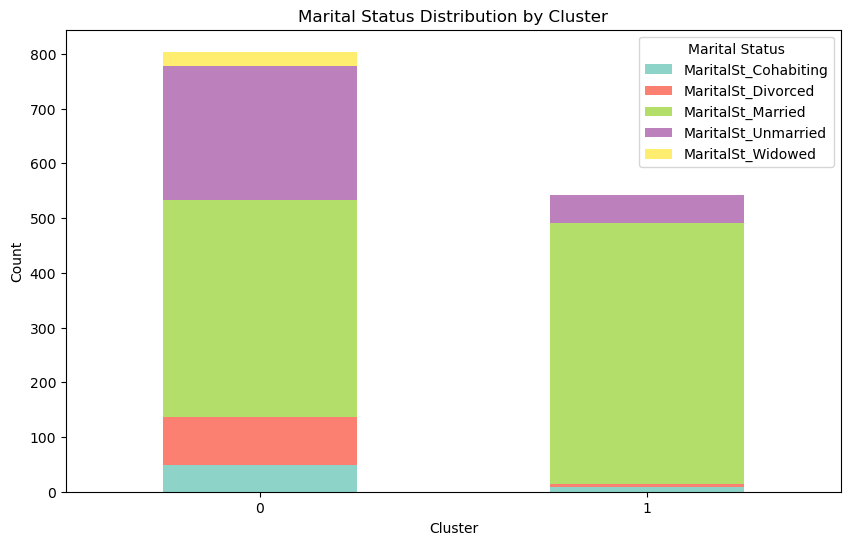

In [210]:
# Stacked bar chart for Marital Status by Cluster
marital_status = ['MaritalSt_Cohabiting', 'MaritalSt_Divorced', 'MaritalSt_Married', 'MaritalSt_Unmarried', 'MaritalSt_Widowed']
marital_status_counts = data[marital_status + ['Cluster']].groupby('Cluster').sum()

# Plotting a stacked bar chart
ax = marital_status_counts.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set3')
plt.title('Marital Status Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Marital Status', loc='upper right')
plt.show()


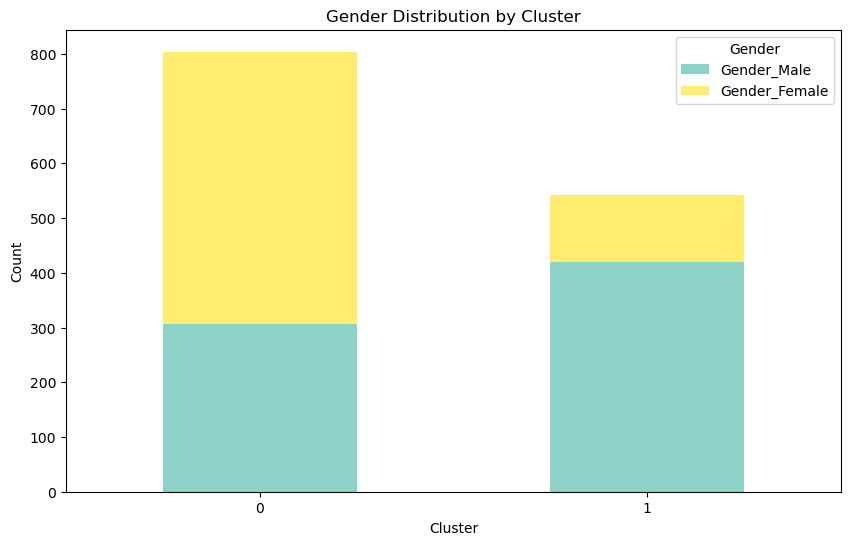

In [211]:
# Stacked bar chart for Gender by Cluster
gender = ['Gender_Male', 'Gender_Female']
gender_counts = data[gender + ['Cluster']].groupby('Cluster').sum()

# Plotting a stacked bar chart
ax = gender_counts.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set3')
plt.title('Gender Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Gender', loc='upper right')
plt.show()


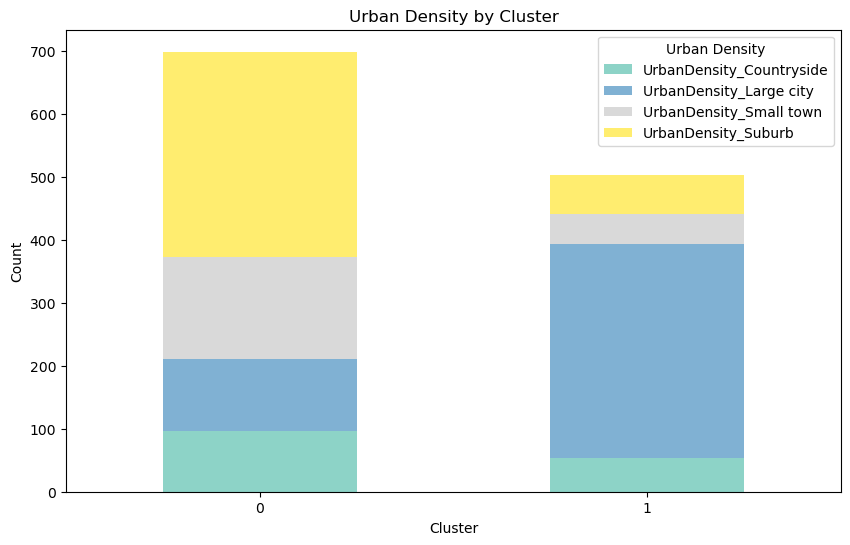

In [212]:
# Stacked bar chart for Urban Density by Cluster
urbandensity = ['UrbanDensity_Countryside', 
          'UrbanDensity_Large city', 'UrbanDensity_Small town', 'UrbanDensity_Suburb']
urbandensity_counts = data[urbandensity + ['Cluster']].groupby('Cluster').sum()

# Plotting a stacked bar chart
ax = urbandensity_counts.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set3')
plt.title('Urban Density by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Urban Density', loc='upper right')
plt.show()

In [ ]:
# Random Forest Model 

In [214]:
# To fix the seed
random_state = 42
# Or any other number that you prefer inside of random.seed or np.random.seed()

In [215]:

# Defining the predictor variables (news consumption + demographics) and target variable (outgroup thermometer)

# Creating the train and test based on features and response separation as new subsets
X_train = data[['NewspaperConsumption_normalised', 
              'WebNewsConsumption_normalised', 
              'SMNewsConsumption_normalised', 
              'BroadcastNewsConsumption_normalised', 
              'Generation_encoded', 
              'Gender_Male', 'Gender_Female', 
          'MaritalSt_Cohabiting', 'MaritalSt_Divorced', 
          'MaritalSt_Married', 'MaritalSt_Unmarried', 
          'MaritalSt_Widowed', 'UrbanDensity_Countryside', 
          'UrbanDensity_Large city', 'UrbanDensity_Small town', 'UrbanDensity_Suburb', 'Income_normalized' ]]

y_train = data['OutgroupThermometer_normalised']

X_test = data[['NewspaperConsumption_normalised', 
              'WebNewsConsumption_normalised', 
              'SMNewsConsumption_normalised', 
              'BroadcastNewsConsumption_normalised', 
              'Generation_encoded', 
              'Gender_Male', 'Gender_Female', 
          'MaritalSt_Cohabiting', 'MaritalSt_Divorced', 
          'MaritalSt_Married', 'MaritalSt_Unmarried', 
          'MaritalSt_Widowed', 'UrbanDensity_Countryside', 
          'UrbanDensity_Large city', 'UrbanDensity_Small town', 'UrbanDensity_Suburb', 'Income_normalized']]

y_test = data['OutgroupThermometer_normalised']

In [216]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Initialize the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=10, max_depth=10, random_state=42)

# Train the model
rf_regressor.fit(X_train, y_train)

# Make predictions
y_predict = rf_regressor.predict(X_test)

# Evaluate performance (e.g., Mean Squared Error)
mse = mean_squared_error(y_test, y_predict)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.019095766927954894


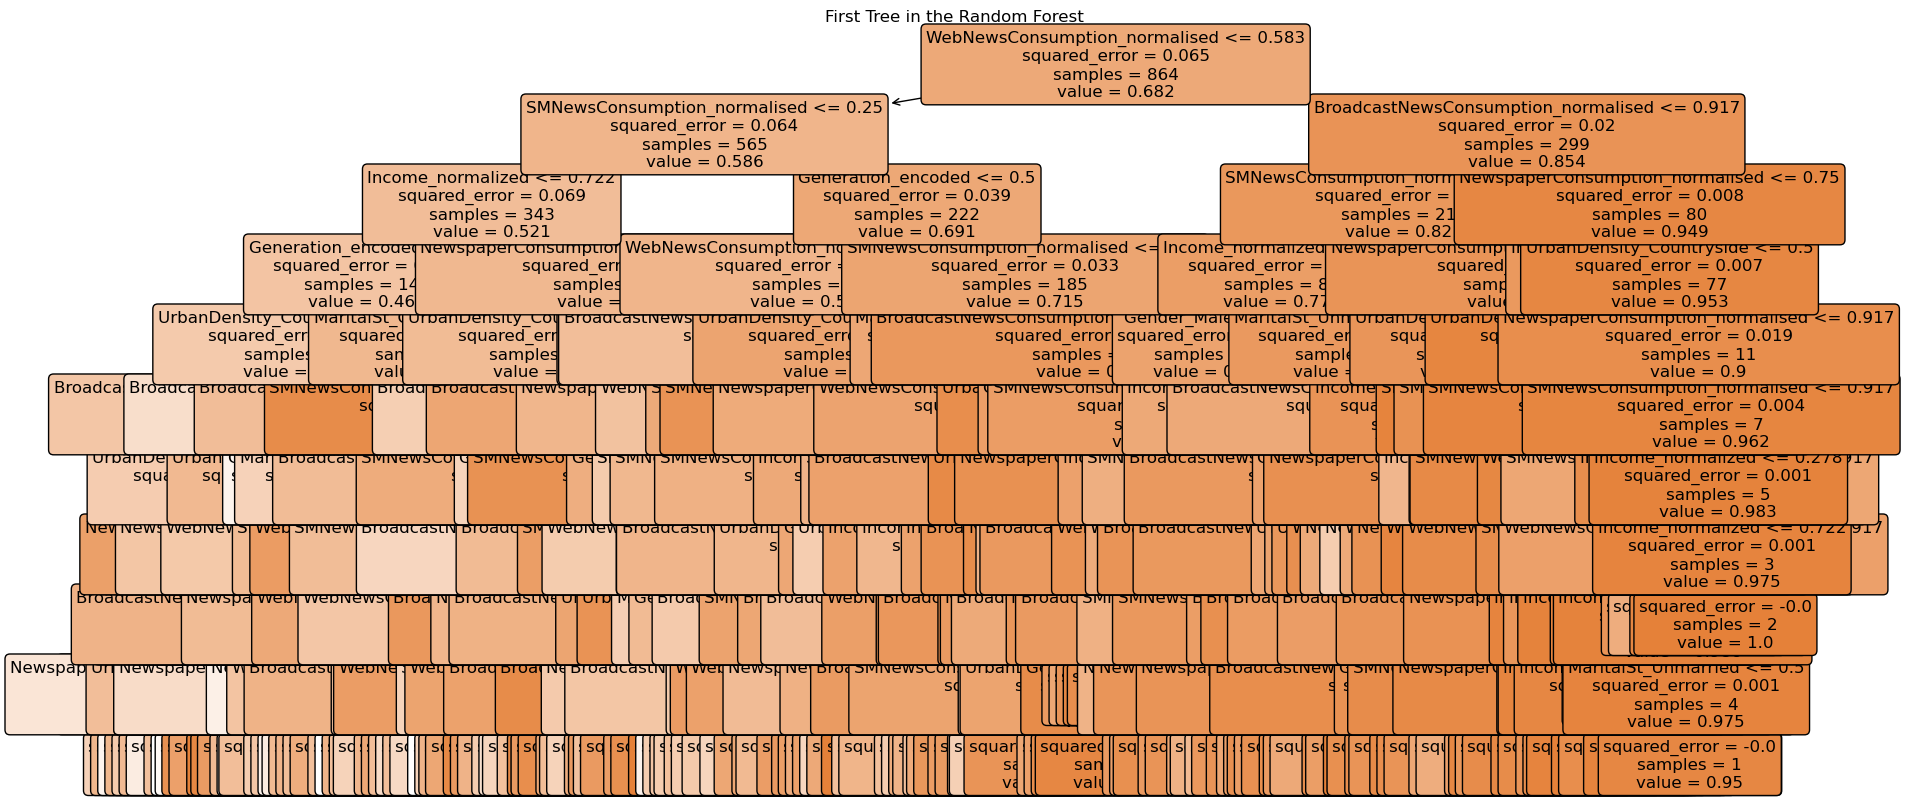

In [217]:
# Visualize the first tree in the random forest
plt.figure(figsize=(20,10))
plot_tree(rf_regressor.estimators_[0], filled=True, feature_names=X_train.columns, rounded=True, fontsize=12)
plt.title("First Tree in the Random Forest")
plt.show()

In [218]:
# Predict the target variable (Outgroup Thermometer) on the test set
y_pred = rf_regressor.predict(X_test)

# Calculate the Mean Squared Error (MSE) to evaluate the model’s accuracy
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Optional: Calculate R-squared to evaluate goodness of fit
r2_score = rf_regressor.score(X_test, y_test)
print(f'R-squared: {r2_score}')


Mean Squared Error: 0.019095766927954894
R-squared: 0.6851484112948655


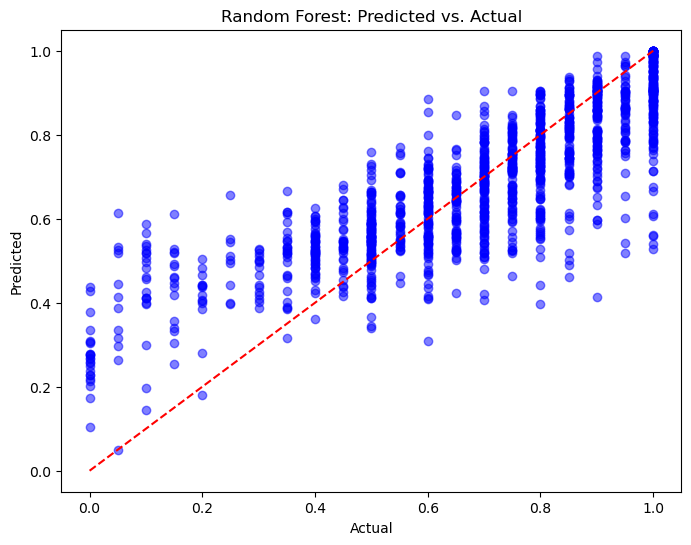

In [219]:
# Plot predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predict, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Line of perfect prediction
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest: Predicted vs. Actual')
plt.show()


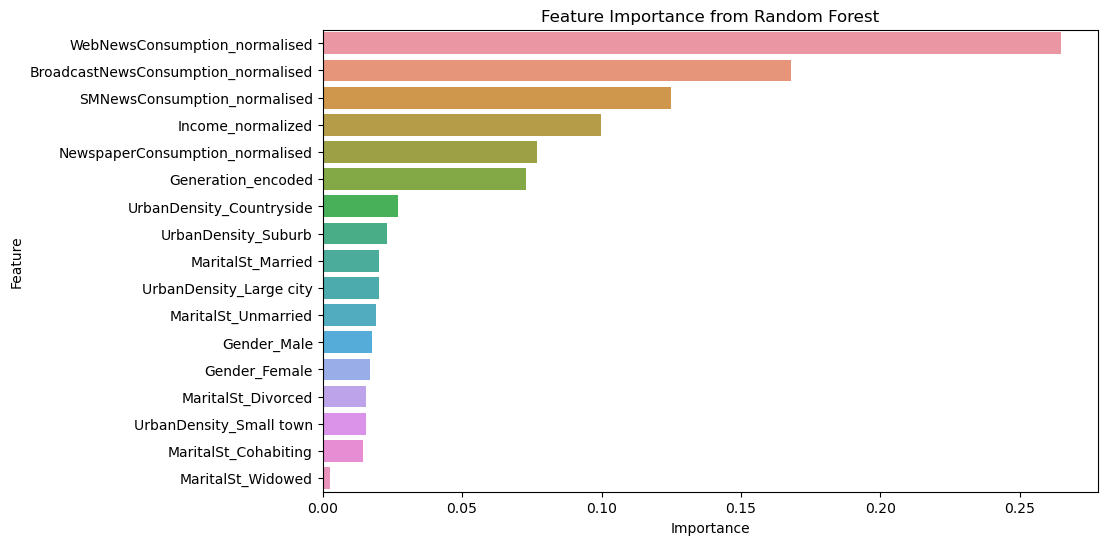

In [228]:
# Get feature importances from the Random Forest model
feature_importances = rf_regressor.feature_importances_

# Create a DataFrame for better visualization
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from Random Forest')
plt.show()



In [226]:
# Fit a Multiple Linear Regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)

# Evaluate performance using Mean Squared Error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error for Linear Regression: {mse}')


Mean Squared Error for Linear Regression: 0.03456196407202586


Model coefficients:  [ 0.02462773  0.13108556  0.11101413  0.13743061  0.01240381  0.00730884
 -0.00730884  0.03627358 -0.0084404   0.00964465  0.00541584 -0.04289368
 -0.03020237  0.00989024  0.00764881  0.01087404  0.02713189]
R2 score: 0.2947525105383517
Mean Squared Error (MSE): 0.03456196407202586
Mean Absolute Error (MAE): 0.1376475107950038


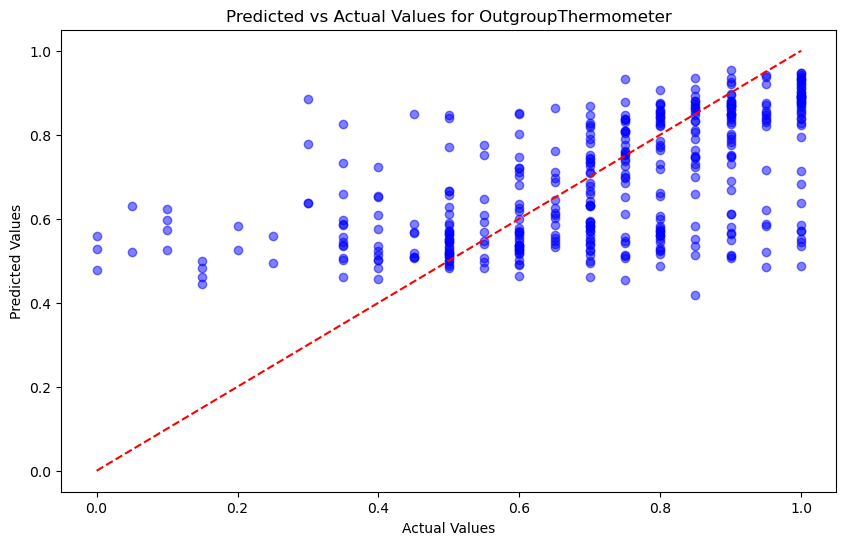

In [227]:
# Print model coefficients to understand feature influence
print("Model coefficients: ", model.coef_)

# Evaluate the model performance using R2 (coefficient of determination)
r2_score = model.score(X_test, y_test)
print(f"R2 score: {r2_score}")

# Evaluate the model using Mean Squared Error (MSE) and Mean Absolute Error (MAE)
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Generate predictions
y_pred = model.predict(X_test)

# Calculate MSE and MAE
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")

# Optionally, you can visualize the predictions vs actual values
import matplotlib.pyplot as plt

# Plotting predicted vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # line of perfect prediction
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values for OutgroupThermometer")
plt.show()
